### Supplemental Figures S16-S22 - Extended clustering analysis

This script generates supplemental figures for the functional clustering analysis,
including cluster selection validation, individual cluster coding profiles,
clustering validation controls (shuffle analysis, familiar-only clustering),
and prediction strength analysis.

Supplemental figures:
- S16: Cluster number selection (gap statistic, eigengap, silhouette scores)
- S17: Individual cluster coding profiles
- S18: Clustering validation (correlations, co-clustering, shuffle control)
- S19: Additional cluster characterization (coding scores, cre-line means)
- S20-S22: Distribution of clusters across areas, depths, and cell types
- Additional: Familiar-only clustering control and prediction strength analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # non-interactive backend
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import scipy.stats as stats
from scipy.special import comb

import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities
import visual_behavior.visualization.utils as utils

from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.p

In [2]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

experience_level_colors = utils.get_experience_level_colors()
cre_line_colors = utils.get_cre_line_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

glm_version = '24_events_all_L2_optimize_by_session'

# Main clustering parameters
n_clusters = 14
n_clusters_familiar = 10  # For familiar-only clustering control

# Create save directories
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5_supplemental')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

### Data Loading

#### Metadata tables

In [3]:
# Cache directory
platform_cache_dir = loading.get_platform_analysis_cache_dir()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, "all_ophys_experiments_table.csv"), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_ophys_experiments_table.csv"), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_ophys_cells_table.csv"), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_matched_ophys_cells_table.csv"), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


#### GLM & clustering results

In [4]:
data_dir = loading.get_clustering_results_dir()

# Load clustering results (main clustering with n_clusters=14)
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

cluster_meta = pd.read_hdf(os.path.join(data_dir, 'cluster_metadata_' + str(n_clusters) + '_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

cluster_order = np.sort(cluster_meta.cluster_id.unique())

# Load GLM results for coding score analysis
glm_results_dir = loading.get_glm_results_dir()
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')

# Get GLM weights
weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_weights_df.h5'), key='df')
weights_df['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in weights_df.experience_level.values]
weights_df = weights_df.merge(platform_experiments[['cell_type']], on='ophys_experiment_id', how='left')
weights_df = weights_df.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id', how='left')

run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
kernels = run_params['kernels']



#### Multi-Session Dataframes

In [5]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# # Remove outliers
# threshold_percentile = 99.8  # for removing outliers for pl
# image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
# change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
# omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.pkl
there are 1881 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.pkl
there are 1879 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


## Plotting

### Cluster methods 

#### Cluster Number Selection (Gap Statistic, Eigengap, Silhouette)

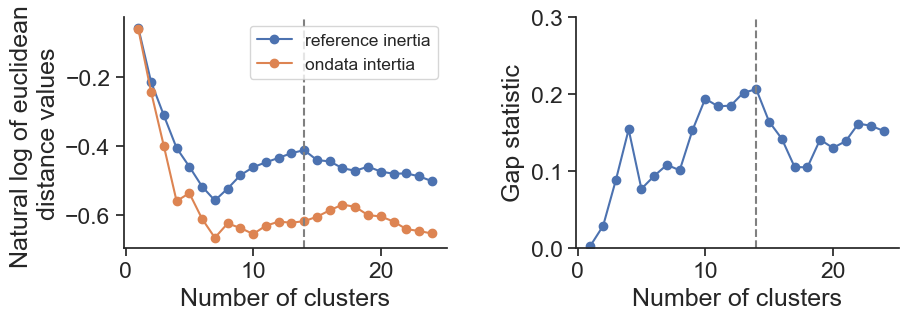

In [48]:
metric = 'euclidean'
shuffle_type = 'all'
k_max = 25

gap_filename = os.path.join(data_dir, f'gap_scores_{metric}_{glm_version}_nb20_unshuffled_to_{shuffle_type}.pkl')
with open(gap_filename, 'rb') as f:
    gap_dict = pickle.load(f)

plotting.plot_gap_statistic(gap_dict, cre_lines=['all'], n_clusters_cre=n_clusters, tag='with_cre_shuffle', save_dir=save_dir, folder='selecting_k_clusters')


loading eigengap values scores from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/eigengap_24_events_all_L2_optimize_by_session_kmax25_all.pkl
done


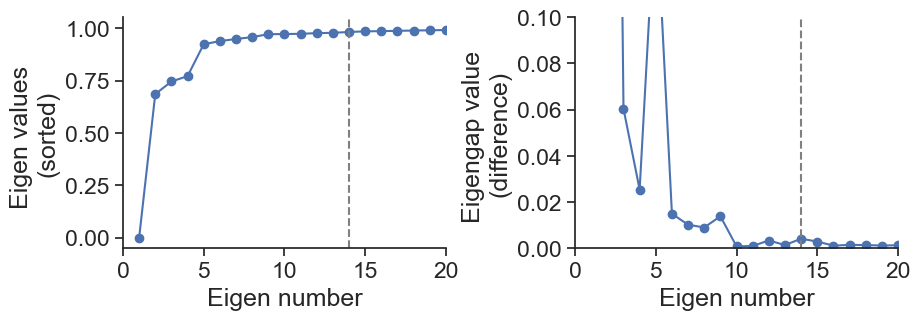

In [49]:

# Eigengap values
eigengap = processing.load_eigengap(glm_version, feature_matrix, cre_line='all', save_dir=data_dir, k_max=25)

plotting.plot_eigengap_values(eigengap, cre_lines=['all'], n_clusters_cre={'all': n_clusters}, save_dir=save_dir, folder='selecting_k_clusters')


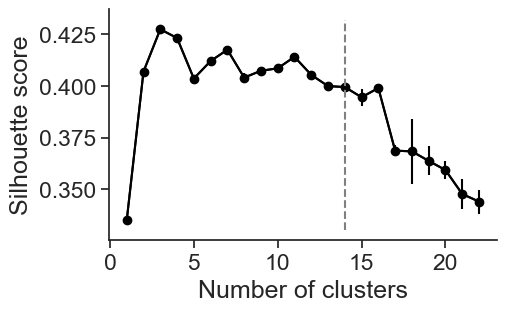

In [50]:

# Silhouette scores
n_clusters_range = np.arange(3, 25)
silhouette_filename = os.path.join(data_dir, f'silhouette_score_{n_clusters_range[0]}_{n_clusters_range[-1]}_clusters_metric_{metric}_nboots_20.pkl')

if os.path.exists(silhouette_filename):
    with open(silhouette_filename, 'rb') as f:
        silhouette_scores, silhouette_std = pickle.load(f)

    plotting.plot_silhouette_scores(
        silhouette_scores=silhouette_scores, silhouette_std=silhouette_std,
        n_clusters=n_clusters, save_dir=save_dir, folder='selecting_k_clusters')

#### Distribution of mice across clusters

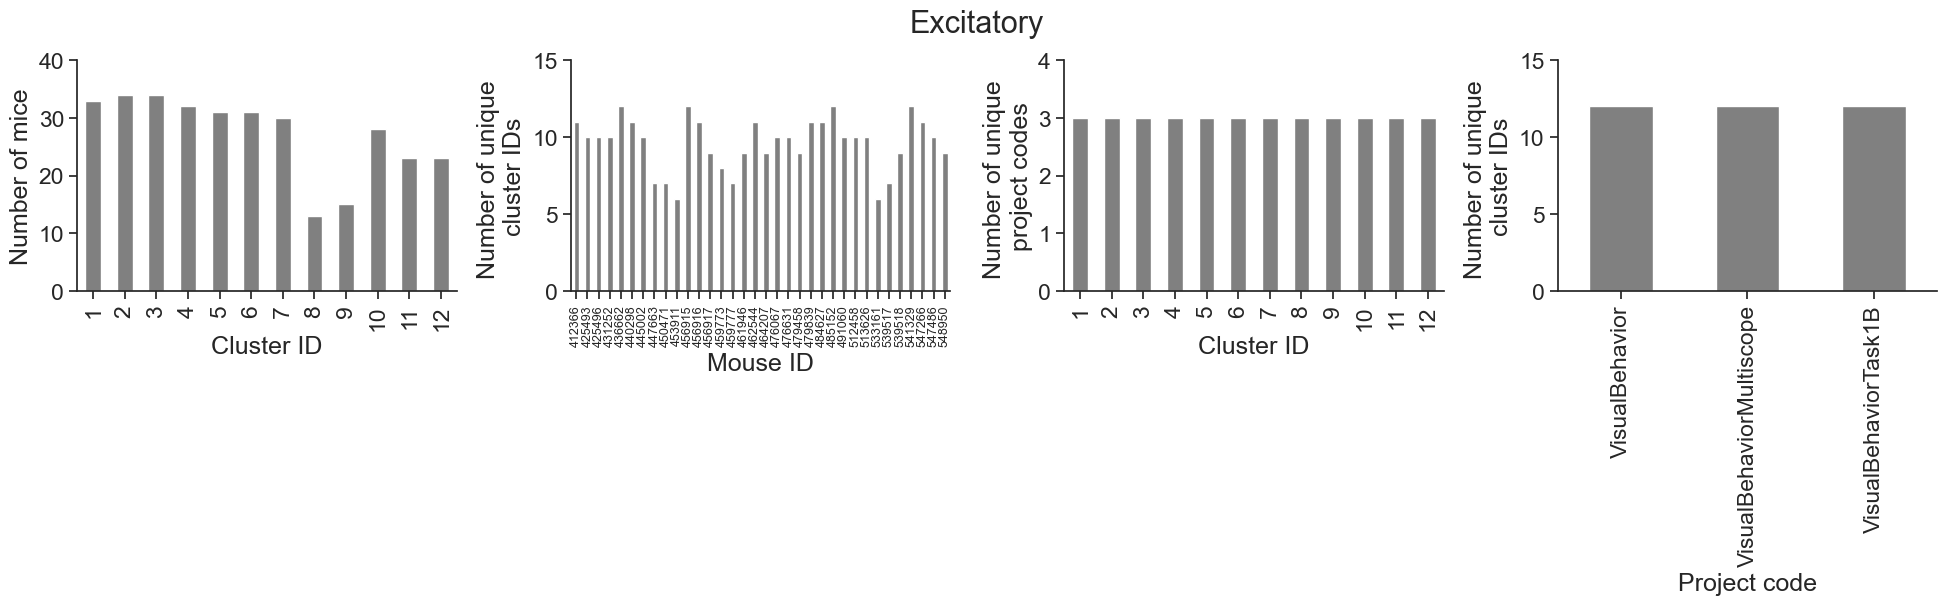

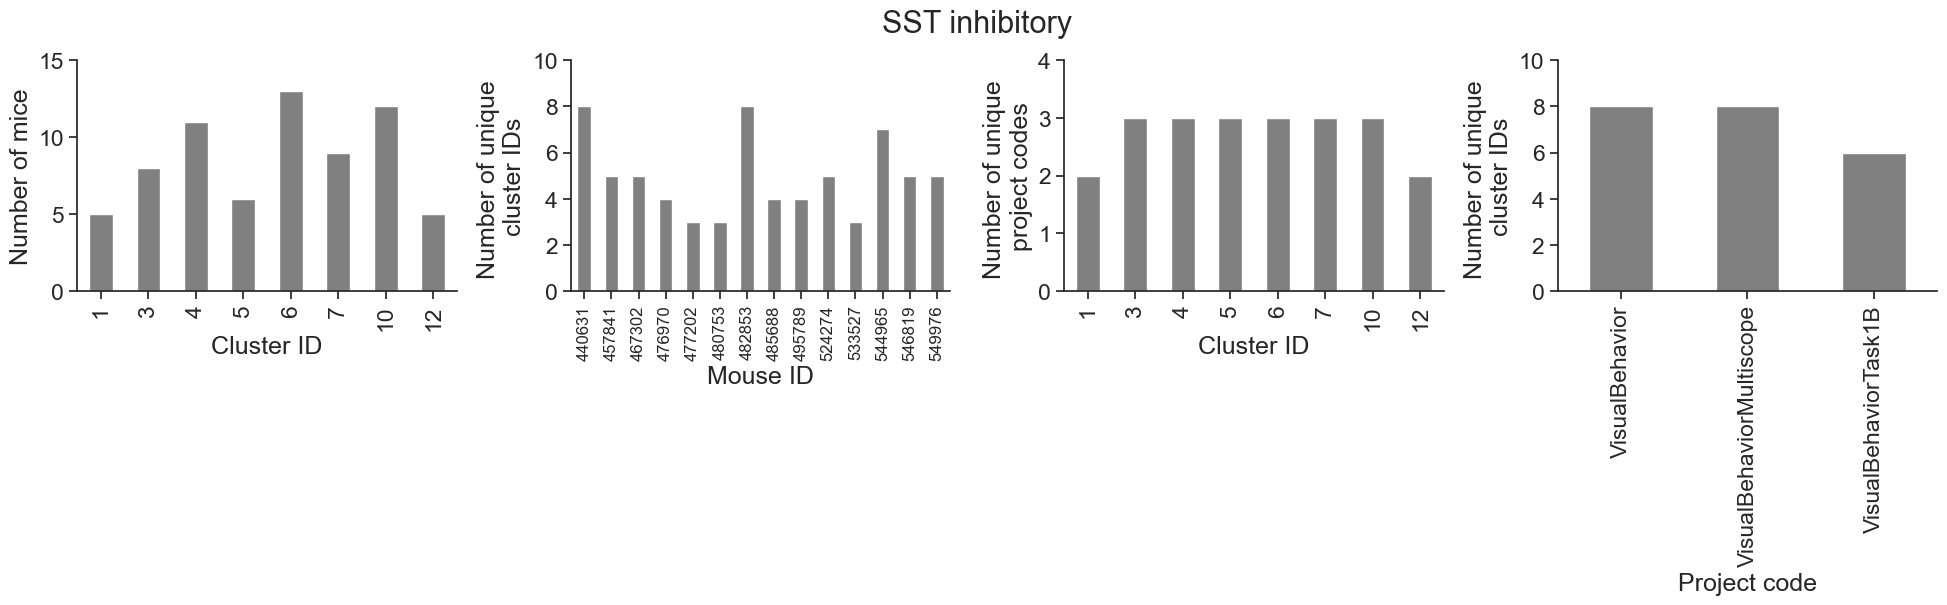

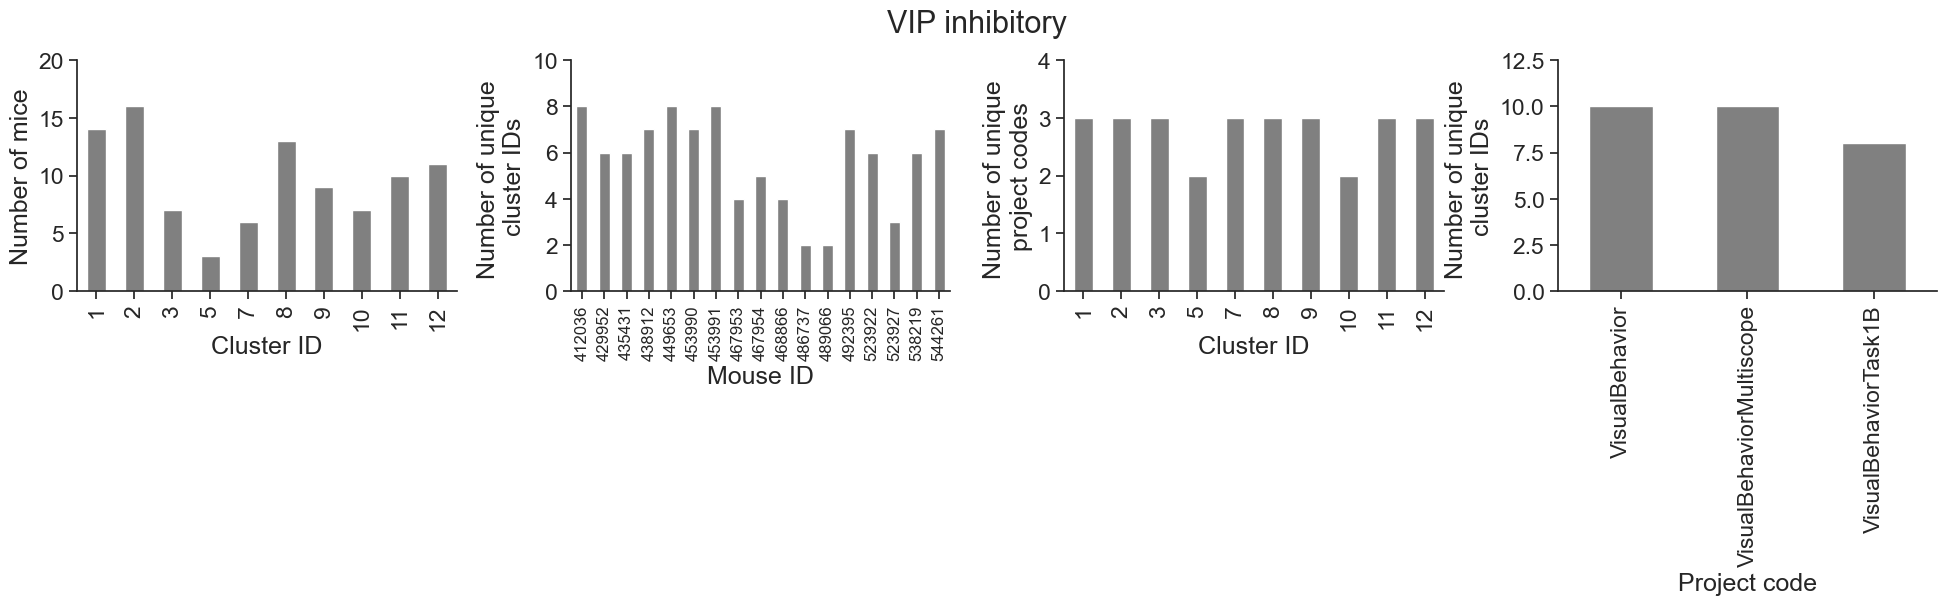

In [51]:
# Cluster info
plotting.plot_cluster_info(
    cre_lines, cluster_meta, save_dir=save_dir, folder='clustering_controls')


#### Proportion cells per cluster per mouse

Not really a far comparison given that different depths are sampled in different mice

In [ ]:
tmp = cluster_meta.copy()
# tmp = tmp[tmp.mouse_id.isin(novel_1_mice)]
n_cells_mice = processing.get_cluster_proportion_stats_for_locations(tmp, location='mouse_id')
n_cells_mice = n_cells_mice.reset_index()
n_cells_mice.head(6)

NameError: name 'novel_1_mice' is not defined

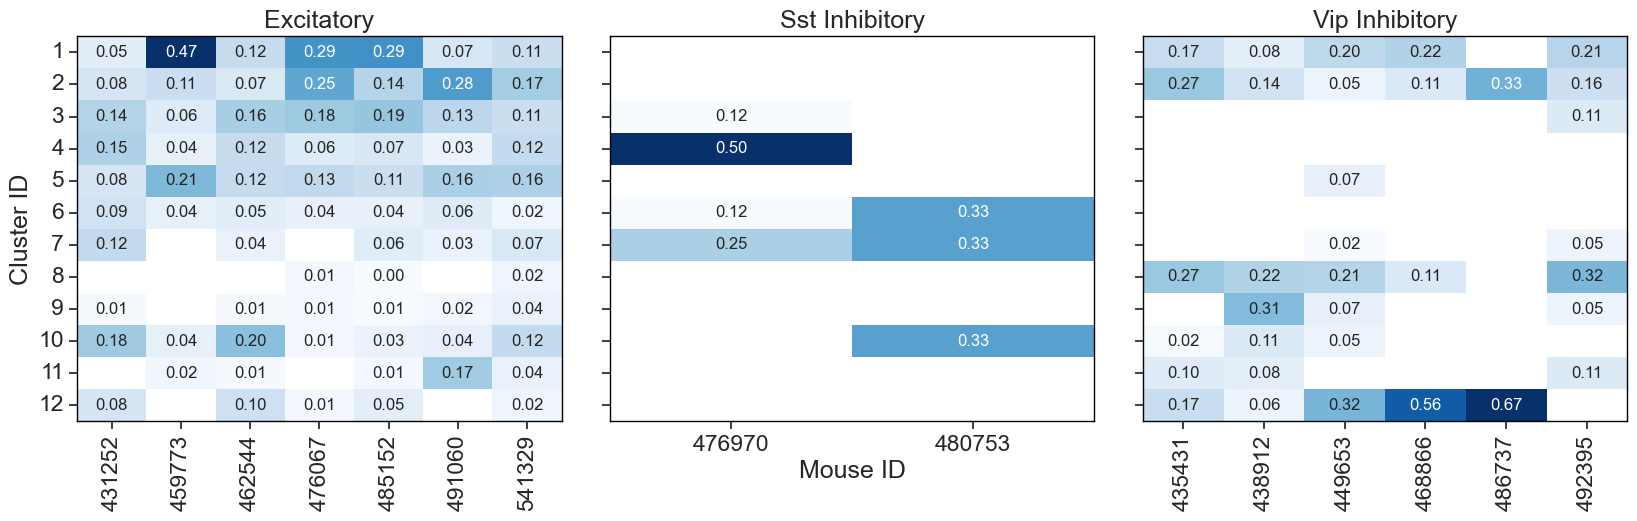

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(20,5), sharey=True)
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    data = n_cells_mice[n_cells_mice.cre_line==cre_line]
    pivot = data.pivot_table(index='cluster_id', columns='mouse_id', values='fraction_cells_location')
    # fill in blank values
    for cluster_id in np.arange(1, 13,1): 
        if cluster_id not in pivot.index.values: 
            pivot.loc[cluster_id] = np.nan
    # order
    pivot = pivot.loc[np.arange(1, 13,1)]
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], 
                        annot=True, fmt=".2f", annot_kws={"fontsize": 12}, cbar=False,
                        cbar_kws={'label':'fraction cells per depth'})
    ax[i].set_yticklabels(pivot.index.values, rotation=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Mouse ID')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1) 
fig.subplots_adjust(wspace=0.1)

#### UMAP


using provided umap_df


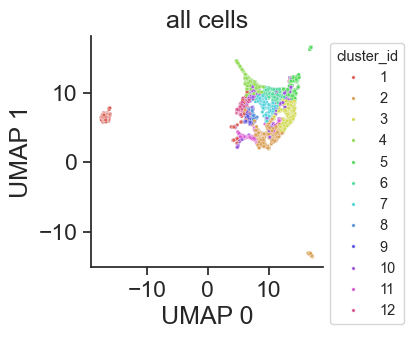

In [ ]:
umap_filename = os.path.join(data_dir, 'umap_results_df.h5')
umap_df = pd.read_hdf(umap_filename, key='df')

# show all clusters in same plot
plotting.plot_umap_for_clusters(cluster_meta, feature_matrix, umap_df, label_col='cluster_id', cre_lines = ['all'],
                                save_dir=save_dir, folder='cluster_results')

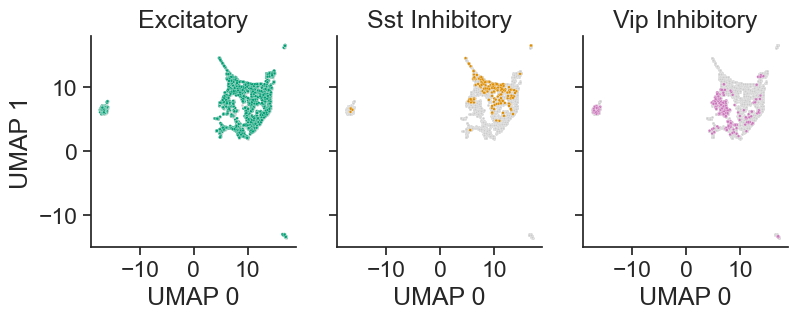

In [ ]:

# UMAP for features separately
feature_colors = plotting.get_feature_colors_with_gray()
cell_type_colors = utils.get_cell_type_colors()
umap_filename = os.path.join(data_dir, 'umap_results_df.h5')
umap_df = pd.read_hdf(umap_filename, key='df')

plotting.plot_umap_for_features_separately(
    cluster_meta, feature_matrix, umap_df, label_col='cell_type',
    cmap=cell_type_colors, save_dir=save_dir, folder='clustering_results')


#### Within cluster correlation

In [ ]:
# Compute within-cluster correlation (Pearson and Spearman) for each cell
cluster_meta = processing.add_within_cluster_corr_to_cluster_meta(
    feature_matrix, cluster_meta, use_spearmanr=False)
cluster_meta = cluster_meta.rename(columns={"within_cluster_correlation": "within_cluster_correlation_p"})
cluster_meta = processing.add_within_cluster_corr_to_cluster_meta(
    feature_matrix, cluster_meta, use_spearmanr=True)
cluster_meta = cluster_meta.rename(columns={"within_cluster_correlation": "within_cluster_correlation_s"})
# Keep a generic version for plotting
cluster_meta["within_cluster_correlation"] = cluster_meta["within_cluster_correlation_p"]

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:765: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(1, n_clusters+1))
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:765: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(1, n_clusters+1))


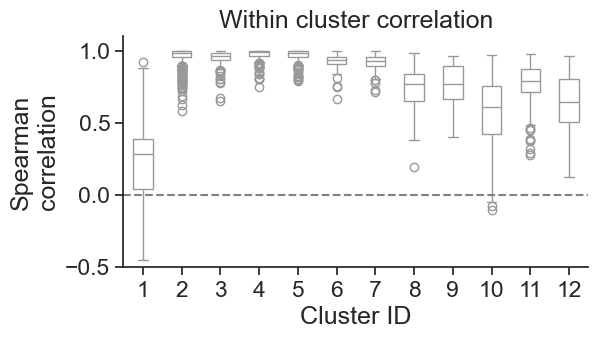

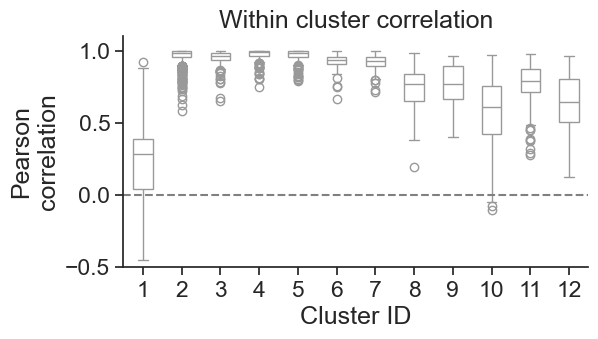

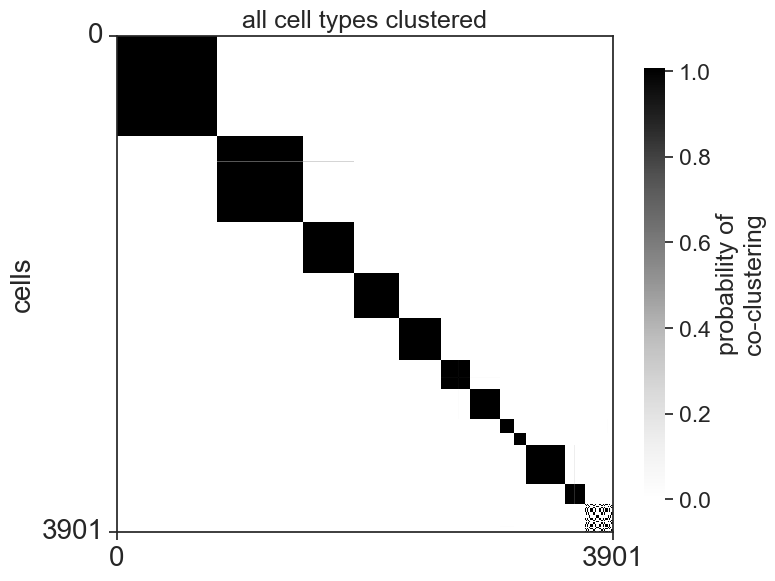

In [ ]:
plotting.plot_within_cluster_correlations(
    cluster_meta, sort_order=None, spearman=True,
    suffix='_' + str(n_clusters) + '_clusters',
    save_dir=save_dir, folder='clustering_controls')

plotting.plot_within_cluster_correlations(
    cluster_meta, sort_order=None, spearman=False,
    suffix='_' + str(n_clusters) + '_clusters',
    save_dir=save_dir, folder='clustering_controls')

# Co-clustering matrix
coclustering_filename = os.path.join(
    data_dir, f'coclustering_matrix_n_{n_clusters}_clusters.h5')
if os.path.exists(coclustering_filename):
    coclustering_df = pd.read_hdf(coclustering_filename, key='df')
    coclustering_dict = {'all': coclustering_df}
    cluster_meta_tmp = cluster_meta.copy()
    cluster_meta_tmp['cre_line'] = 'all'

    plotting.plot_coclustering_matrix_sorted_by_cluster_size(
        coclustering_dict, cluster_meta_tmp, cre_line='all',
        save_dir=save_dir, folder='clustering_controls',
        suffix='_' + str(n_clusters) + '_clusters')


### Cluster properties

#### Coding scores & average responses

In [ ]:
print("Generating Panel B: Cluster means...")
plotting.plot_cluster_means_remapped(
    feature_matrix,
    cluster_meta,
    save_dir=save_dir,
    folder='figure_5_panels')


In [ ]:
# All cre lines combined
tmp = cluster_meta.copy()
tmp['cre_line'] = 'all'

plotting.plot_cluster_properties_combined(
    tmp,
    feature_matrix,
    'all',
    image_mdf,
    change_mdf,
    omission_mdf,
    save_dir=save_dir)

# By individual cre line
for cre_line in cre_lines:
    plotting.plot_cluster_properties_combined(
        cluster_meta,
        feature_matrix,
        cre_line,
        image_mdf,
        change_mdf,
        omission_mdf,
        save_dir=save_dir,
        sort_by='cluster_size')


#### Average kernels

In [ ]:
def plot_cluster_kernel_overlays_by_experience(
    weights_df,
    run_params,
    kernels_to_plot=None,
    cluster_col="cluster_id",
    exp_col="experience_level",
    experience_levels=None,
    experience_level_colors=None,
    sampling_rate=31.0,
    linewidth=1.4,
):
    """
    Plot mean kernel weights with one row per cluster and one column per kernel.
    Each panel overlays experience-level traces in color using utils.plot_mean_trace,
    and adds stimulus timing bars using utils.plot_flashes_on_trace.
    """
    if kernels_to_plot is None:
        kernels_to_plot = ["all-images", "omissions", "hits", "misses", "running", "pupil", "licks"]

    df = weights_df.copy()
    df = df[df[cluster_col].notna() & df[exp_col].notna()]

    if experience_levels is None:
        if "experience_levels" in globals():
            ordered_experience_levels = [
                level for level in experience_levels
                if level in df[exp_col].unique()
            ]
        else:
            ordered_experience_levels = sorted(df[exp_col].dropna().unique())
    else:
        ordered_experience_levels = [
            level for level in experience_levels
            if level in df[exp_col].unique()
        ]

    if experience_level_colors is None:
        experience_level_colors = utils.get_experience_level_colors()

    color_map = {
        level: experience_level_colors[i % len(experience_level_colors)]
        for i, level in enumerate(ordered_experience_levels)
    }

    clusters = np.sort(df[cluster_col].unique())
    n_rows = len(clusters)
    n_cols = len(kernels_to_plot)

    fig_w = n_cols*1.4
    fig_h = n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharex=False, sharey="col", squeeze=False)

    def _kernel_timestamps(kernel_name):
        kernel_for_timestamps = "image0" if kernel_name == "all-images" else kernel_name
        if kernel_for_timestamps not in run_params["kernels"]:
            return None
        offset = run_params["kernels"][kernel_for_timestamps]["offset"]
        length = run_params["kernels"][kernel_for_timestamps]["length"]
        timestamps = np.arange(offset, offset + length, 1 / sampling_rate)
        timestamps = np.round(timestamps, 2)
        if "image" in kernel_name:
            timestamps = timestamps[:-1]
        return timestamps

    def _pad_or_trim(arr, target_len):
        arr = np.asarray(arr)
        if len(arr) == target_len:
            return arr
        if len(arr) > target_len:
            return arr[:target_len]
        return np.pad(arr, (0, target_len - len(arr)), mode="constant", constant_values=np.nan)

    def _interval_sec_from_timestamps(timestamps):
        if np.max(timestamps) < 0.7:
            return 0.2
        if np.max(timestamps) < 1:
            return 0.5
        return 1

    for r, cluster_id in enumerate(clusters):
        cluster_df = df[df[cluster_col] == cluster_id]

        for c, kernel_name in enumerate(kernels_to_plot):
            ax = axes[r, c]
            weight_col = f"{kernel_name}_weights"

            if weight_col not in cluster_df.columns:
                ax.axis("off")
                continue

            timestamps = _kernel_timestamps(kernel_name)
            if timestamps is None or len(timestamps) == 0:
                ax.axis("off")
                continue

            target_len = len(timestamps)
            interval_sec = _interval_sec_from_timestamps(timestamps)
            xlim_seconds = [-0.01, timestamps[-1]]
            omitted = kernel_name == "omissions"
            change = kernel_name in ["hits", "misses"]

            for exp_level in ordered_experience_levels:
                exp_df = cluster_df[cluster_df[exp_col] == exp_level]
                if len(exp_df) == 0:
                    continue

                traces = []
                for value in exp_df[weight_col].values:
                    if value is None:
                        continue
                    if isinstance(value, float) and np.isnan(value):
                        continue
                    traces.append(_pad_or_trim(value, target_len))

                if len(traces) == 0:
                    continue

                traces = np.vstack(traces)
                ax = utils.plot_mean_trace(
                    traces,
                    timestamps,
                    ylabel="Kernel weights",
                    legend_label=exp_level,
                    color=color_map[exp_level],
                    interval_sec=interval_sec,
                    xlim_seconds=xlim_seconds,
                    linewidth=linewidth,
                    ax=ax,
                )

            ax = utils.plot_flashes_on_trace(ax, timestamps, change=change, omitted=omitted, alpha=0.3)

            if r == 0:
                ax.set_title(kernel_name, fontsize=10)
            if c == 0:
                ax.set_ylabel(f"\n\n{int(cluster_id)}", rotation=0, ha="right", va="center", fontsize=12)
            else:
                ax.set_ylabel("")

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("")
            for spine in ax.spines.values():
                spine.set_visible(False)

            xlim = ax.get_xlim()
            ymin_data, ymax_data = ax.get_ylim()
            x_range = xlim[1] - xlim[0]
            y_range = ymax_data - ymin_data

            y_sb_len = 0.005
            x_sb_y = xlim[0] - x_range * 0.08
            ax.plot([x_sb_y, x_sb_y], [0, -y_sb_len], color="k", linewidth=1.5, clip_on=False)
            if r == n_rows - 1:
                ax.text(x_sb_y - x_range * 0.02, -y_sb_len / 2, "0.005", ha="right", va="center", fontsize=6, clip_on=False)

            if r == n_rows - 1:
                x_sb_len = min(0.5, x_range * 0.45)
                x_sb_start = xlim[0]
                y_sb_x = ymin_data - y_range * 0.40
                ax.plot([x_sb_start, x_sb_start + x_sb_len], [y_sb_x, y_sb_x], color="k", linewidth=1.5, clip_on=False)
                ax.text(x_sb_start + x_sb_len / 2, y_sb_x - y_range * 0.07, f"{x_sb_len:.1f} s", ha="center", va="top", fontsize=6, clip_on=False)

    legend_handles = [
        plt.Line2D([0], [0], color=color_map[level], lw=2)
        for level in ordered_experience_levels
    ]


    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    fig.text(0.005, 0.5, "Cluster ID", va="center", rotation="vertical", fontsize=11)
    fig.suptitle("Average Kernel Weights by Cluster and Experience Level", y=0.93, fontsize=12)
    return fig, axes


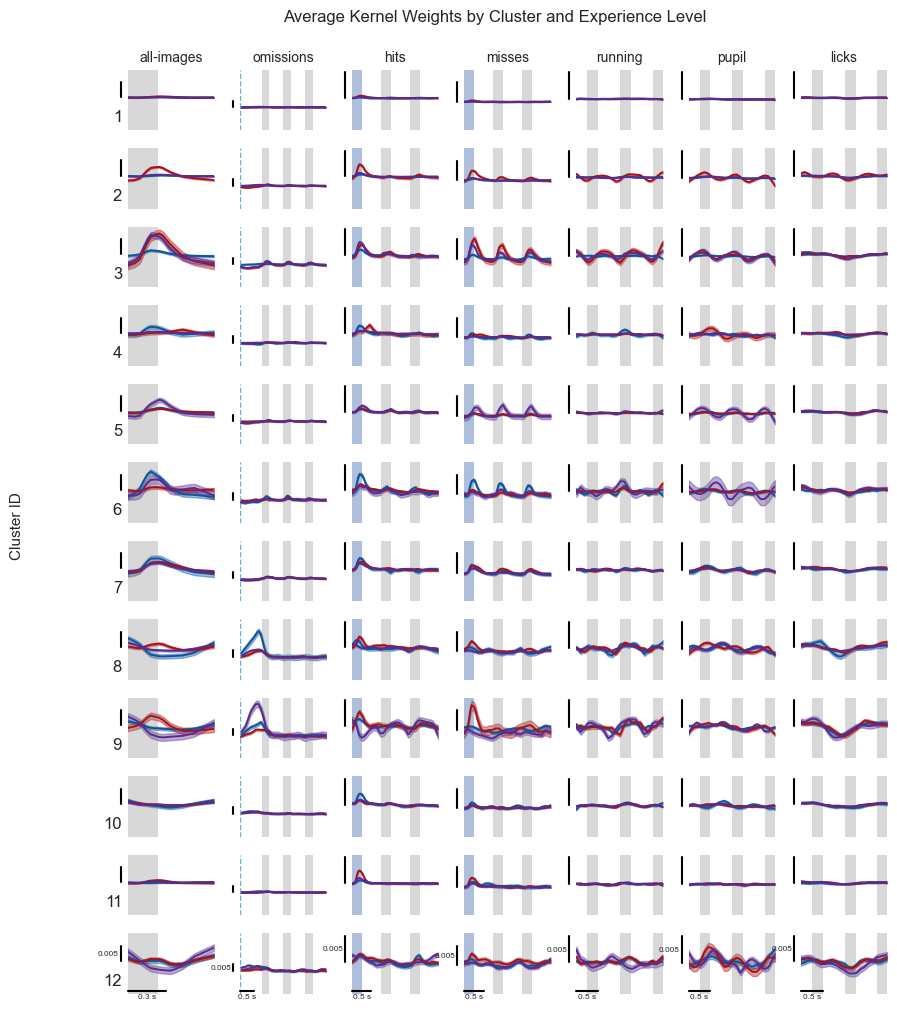

In [ ]:
kernels_for_overlay_plot = ['all-images', 'omissions', 'hits', 'misses', 'running', 'pupil', 'licks']

fig, axes = plot_cluster_kernel_overlays_by_experience(
    weights_df=weights_df,
    run_params=run_params,
    kernels_to_plot=kernels_for_overlay_plot,
    cluster_col='cluster_id',
    exp_col='experience_level',
    experience_levels=experience_levels,
    experience_level_colors=utils.get_experience_level_colors(),
)
plt.show()

#### Kernel heatmaps

In [ ]:
# for cell_type in cell_types:
#     plotting.plot_cell_response_heatmaps_for_clusters(image_mdf[image_mdf.cell_type==cell_type],
#         data_type='events', event_type='images', vmax=0.0005, xlim_seconds=[-0.3, 0.8], suptitle=cell_type, ax=None);


In [337]:
def prepare_and_plot_concatenated_image_kernels(
    kernel_names,
    weights_df,
    run_params,
    experience_levels=None,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Time (s)',
    suptitle=None,
    plot=True,
    split_by_cell_type=False,
    cell_types_to_plot=None,
):
    """
    Reformat weights into per-experience concatenated kernels and optionally plot.

    Returns
    -------
    reformatted_weights_df : pd.DataFrame
        One row per (cluster_id, cell_type, cell_specimen_id), one column per experience level.
    melted_weights_df : pd.DataFrame
        Long-form dataframe with '<kernel_name>_weights' used by GLM plotting code.
    run_params_tmp : dict
        Copy of run_params with a kernel definition for the plotted kernel.
    """
    import copy
    import visual_behavior.visualization.ophys.glm_example_plots as gep

    index_cols = ['cluster_id', 'cell_type', 'cell_specimen_id']

    if 'concatenated_images' in kernel_names:
        kernel_cols = [f'image{i}_weights' for i in range(8)]
        required_cols = index_cols + ['experience_level'] + kernel_cols
        kernel_name = 'concatenated_image'
    else:
        kernel_name = '_'.join(kernel_names) if len(kernel_names) > 1 else kernel_names[0]
        kernel_cols = [f'{name}_weights' for name in kernel_names]
        required_cols = kernel_cols + index_cols + ['experience_level']

    weights_subset = weights_df[required_cols].copy()
    weights_subset = weights_subset.dropna(subset=index_cols + ['experience_level'])

    if experience_levels is not None:
        ordered_experience_levels = [
            level for level in experience_levels
            if level in weights_subset['experience_level'].unique()
        ]
    else:
        ordered_experience_levels = sorted(weights_subset['experience_level'].dropna().unique())

    weights_subset['experience_level'] = pd.Categorical(
        weights_subset['experience_level'],
        categories=ordered_experience_levels,
        ordered=True,
    )
    weights_subset = weights_subset.sort_values(index_cols + ['experience_level'])

    weights_unique = weights_subset.drop_duplicates(
        subset=index_cols + ['experience_level'],
        keep='first',
    )

    def _concat_kernels(row, cols):
        arrays = []
        for col in cols:
            value = row[col]
            if value is None:
                continue
            if isinstance(value, float) and np.isnan(value):
                continue
            arrays.append(np.asarray(value))
        return np.concatenate(arrays) if len(arrays) > 0 else np.array([])

    weights_unique[f'{kernel_name}_weights'] = weights_unique.apply(
        _concat_kernels,
        axis=1,
        cols=kernel_cols,
    )

    weights_unique['kernel_length'] = weights_unique[f'{kernel_name}_weights'].apply(len)
    nonzero_lengths = weights_unique.loc[weights_unique['kernel_length'] > 0, 'kernel_length']
    expected_kernel_length = int(nonzero_lengths.mode().iloc[0])
    weights_valid = weights_unique[weights_unique['kernel_length'] == expected_kernel_length].copy()

    n_required_levels = len(ordered_experience_levels)
    level_counts = weights_valid.groupby(index_cols)['experience_level'].nunique()
    complete_index = level_counts[level_counts == n_required_levels].index

    weights_complete = (
        weights_valid
        .set_index(index_cols)
        .loc[complete_index]
        .reset_index()
    )

    reformatted_weights_df = (
        weights_complete
        .pivot_table(
            index=index_cols,
            columns='experience_level',
            values=f'{kernel_name}_weights',
            aggfunc='first',
        )
        .reindex(columns=ordered_experience_levels)
        .reset_index()
    )

    melted_weights_df = reformatted_weights_df.melt(
        id_vars=['cell_specimen_id', 'cluster_id', 'cell_type'],
        value_vars=ordered_experience_levels,
    )
    melted_weights_df = melted_weights_df.rename(
        columns={
            'variable': 'experience_level',
            'value': f'{kernel_name}_weights',
        }
    )
    melted_weights_df[f'{kernel_name}_weights'] = melted_weights_df[f'{kernel_name}_weights'].apply(np.asarray)
    melted_weights_df[kernel_name] = 1

    run_params_tmp = copy.deepcopy(run_params)

    # Define kernel timing using onset/length logic consistent with glm plotting code.
    if len(kernel_names) == 1 and kernel_names[0] in run_params['kernels']:
        run_params_tmp['kernels'][kernel_name] = copy.deepcopy(run_params['kernels'][kernel_names[0]])
    elif 'concatenated_images' in kernel_names:
        # Concatenated image kernels are synthetic; use image0 timing as base.
        image0_offset = run_params['kernels']['image0']['offset']
        image0_length = run_params['kernels']['image0']['length']
        run_params_tmp['kernels'][kernel_name] = {
            'offset': image0_offset,
            'length': image0_length * 8,
        }
    else:
        # Concatenation of multiple kernels is synthetic.
        # Use the first kernel onset and summed durations as an explicit convention.
        offsets = [run_params['kernels'][name]['offset'] for name in kernel_names if name in run_params['kernels']]
        lengths = [run_params['kernels'][name]['length'] for name in kernel_names if name in run_params['kernels']]
        run_params_tmp['kernels'][kernel_name] = {
            'offset': offsets[0] if len(offsets) > 0 else 0,
            'length': np.sum(lengths) if len(lengths) > 0 else expected_kernel_length / 31.0,
        }

    # Compute expected bins exactly like plot_weights_and_coding_score_heatmaps_for_experience_levels_main_figure.
    kernel_for_timestamps = 'image0' if kernel_name == 'all-images' else kernel_name
    timestamps = np.arange(
        run_params_tmp['kernels'][kernel_for_timestamps]['offset'],
        run_params_tmp['kernels'][kernel_for_timestamps]['offset'] + run_params_tmp['kernels'][kernel_for_timestamps]['length'],
        1 / 31.0,
    )
    timestamps = np.round(timestamps, 2)
    if 'image' in kernel_name:
        timestamps = timestamps[:-1]
    expected_plot_bins = len(timestamps)

    def _pad_or_trim(arr, target_len):
        arr = np.asarray(arr)
        if len(arr) == target_len:
            return arr
        if len(arr) > target_len:
            return arr[:target_len]
        return np.pad(arr, (0, target_len - len(arr)), mode='constant', constant_values=np.nan)

    melted_weights_df[f'{kernel_name}_weights'] = melted_weights_df[f'{kernel_name}_weights'].apply(
        _pad_or_trim,
        target_len=expected_plot_bins,
    )

    n_unique_cells = weights_unique[index_cols].drop_duplicates().shape[0]
    n_complete_cells = len(complete_index)
    raw_len = int(melted_weights_df[f'{kernel_name}_weights'].apply(len).mode().iloc[0])
    print(
        f"Prepared '{kernel_name}': plotted length={expected_plot_bins}, "
        f"kept {n_complete_cells}/{n_unique_cells} cells with complete experience coverage."
    )

    if plot:
        if split_by_cell_type:
            if cell_types_to_plot is None:
                cell_types_to_plot = np.sort(melted_weights_df['cell_type'].dropna().unique())
            for cell_type in cell_types_to_plot:
                subset_df = melted_weights_df[melted_weights_df['cell_type'] == cell_type]
                gep.plot_weights_and_coding_score_heatmaps_for_experience_levels_main_figure(
                    kernel_name,
                    subset_df,
                    run_params_tmp,
                    row_condition=row_condition,
                    col_condition=col_condition,
                    vmax=vmax,
                    xlabel=xlabel,
                    suptitle=cell_type,
                    save_dir=None,
                    folder=None,
                )
        else:
            gep.plot_weights_and_coding_score_heatmaps_for_experience_levels_main_figure(
                kernel_name,
                melted_weights_df,
                run_params_tmp,
                row_condition=row_condition,
                col_condition=col_condition,
                vmax=vmax,
                xlabel=xlabel,
                suptitle=suptitle,
                save_dir=None,
                folder=None,
            )

    return reformatted_weights_df, melted_weights_df, run_params_tmp

Prepared 'concatenated_image': plotted length=185, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

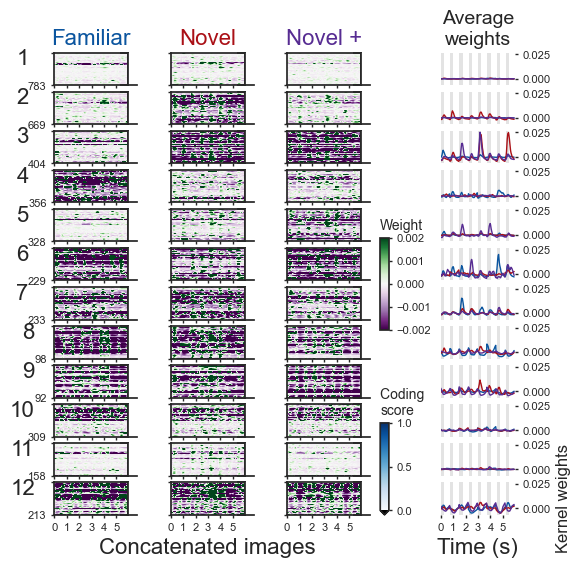

In [338]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = prepare_and_plot_concatenated_image_kernels(
    kernel_names=['concatenated_images'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Concatenated images',
    suptitle=None,
    plot=True,
    split_by_cell_type=False,
)

Prepared 'concatenated_image': plotted length=185, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

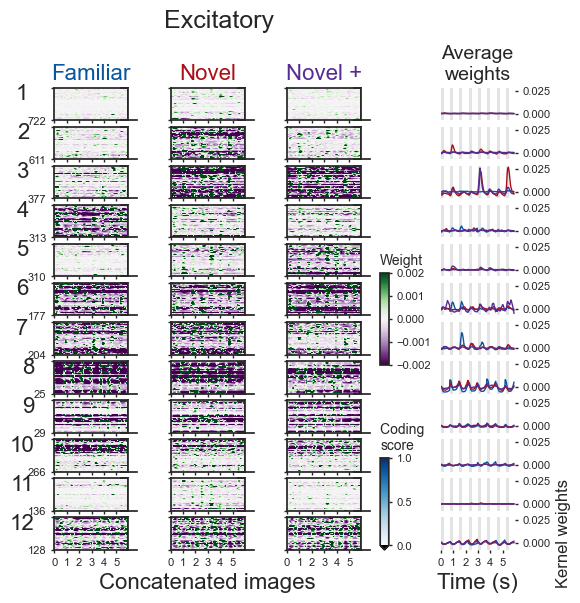

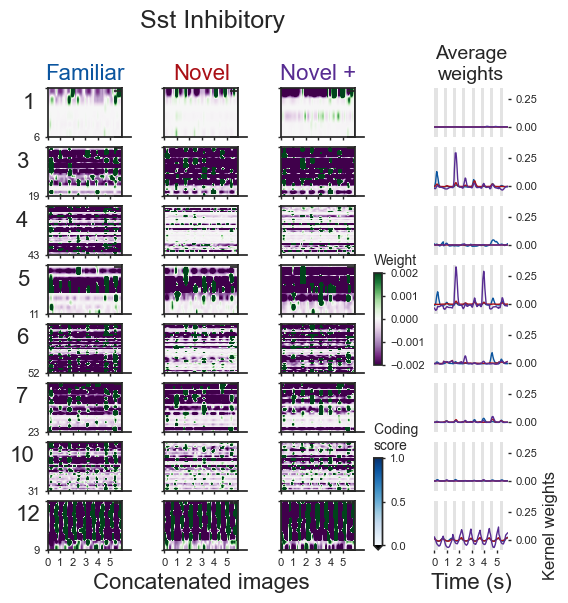

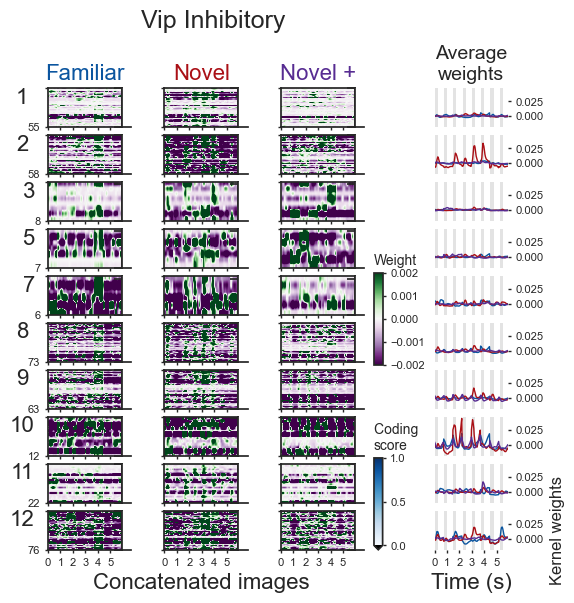

In [328]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = prepare_and_plot_concatenated_image_kernels(
    kernel_names=['concatenated_images'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Concatenated images',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'omissions': plotted length=93, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

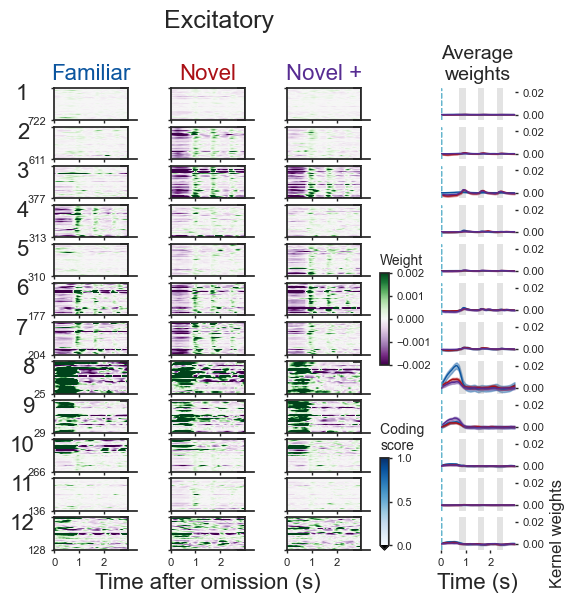

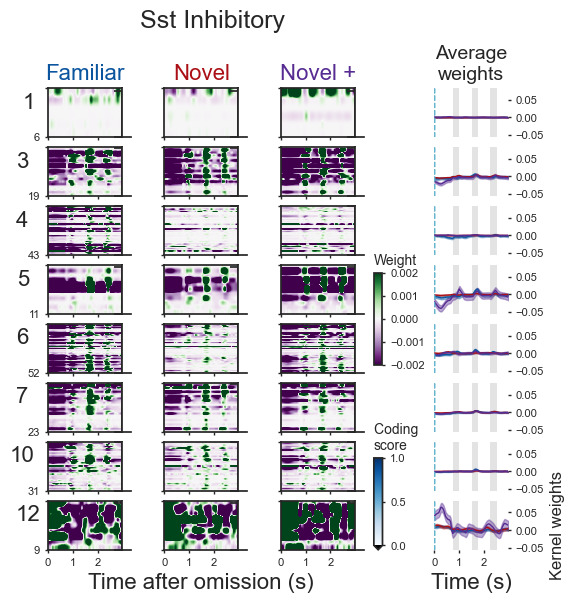

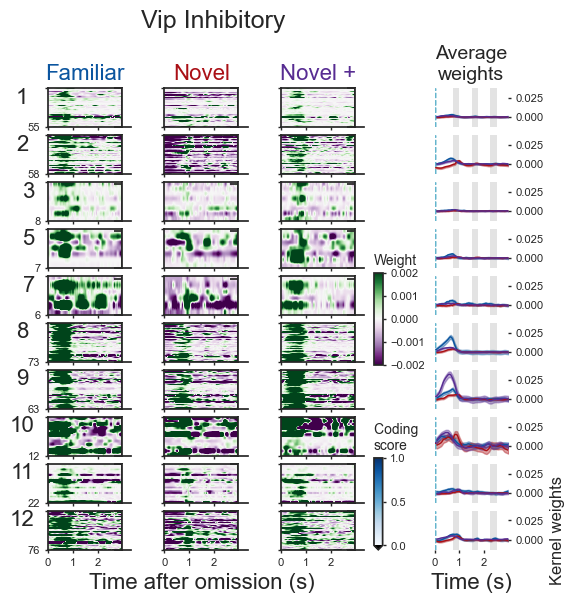

In [329]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = prepare_and_plot_concatenated_image_kernels(
    kernel_names=['omissions'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Time after omission (s)',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'hits_misses': plotted length=140, kept 3857/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

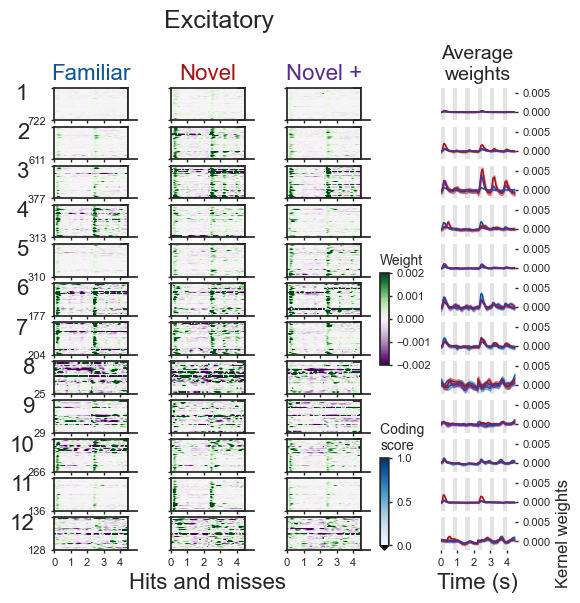

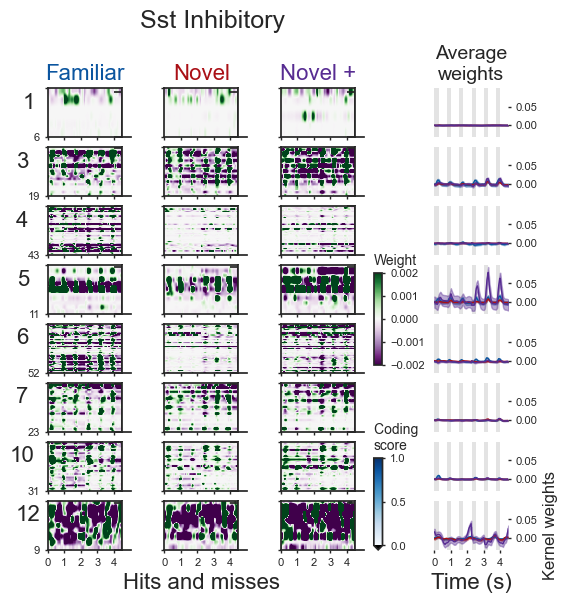

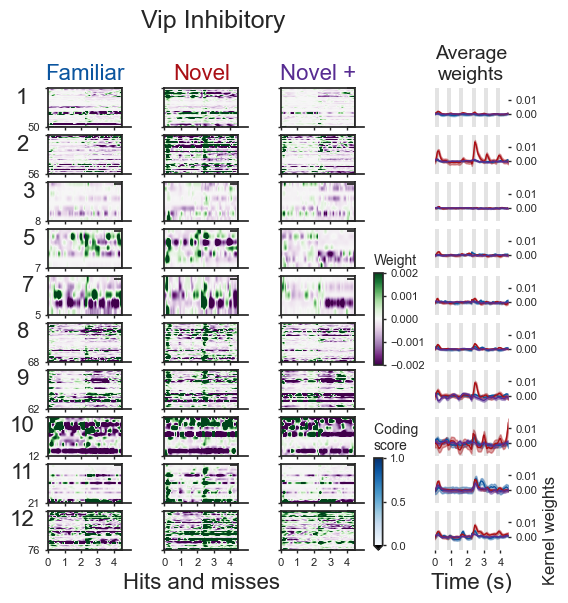

In [330]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = prepare_and_plot_concatenated_image_kernels(
    kernel_names=['hits', 'misses'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Hits and misses',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'licks_running_pupil': plotted length=186, kept 3829/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2860: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

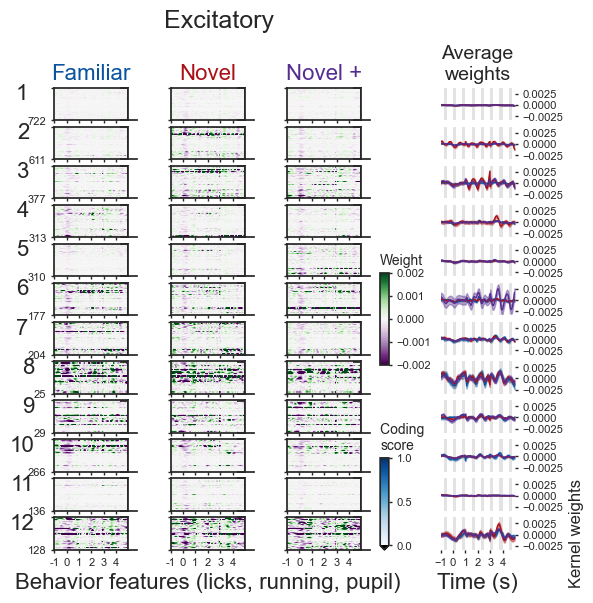

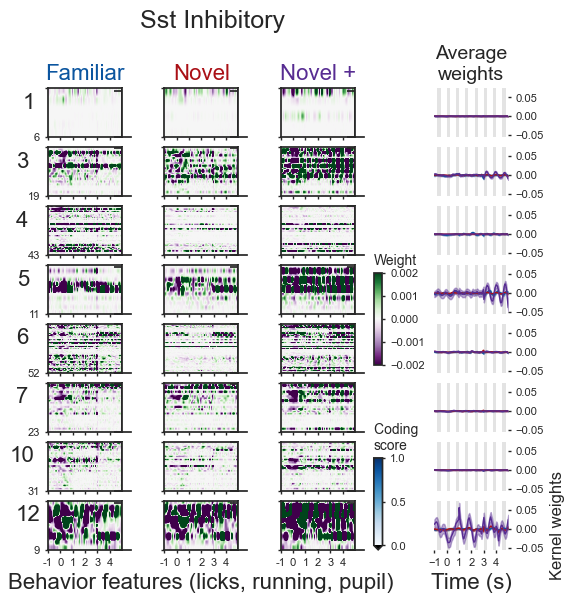

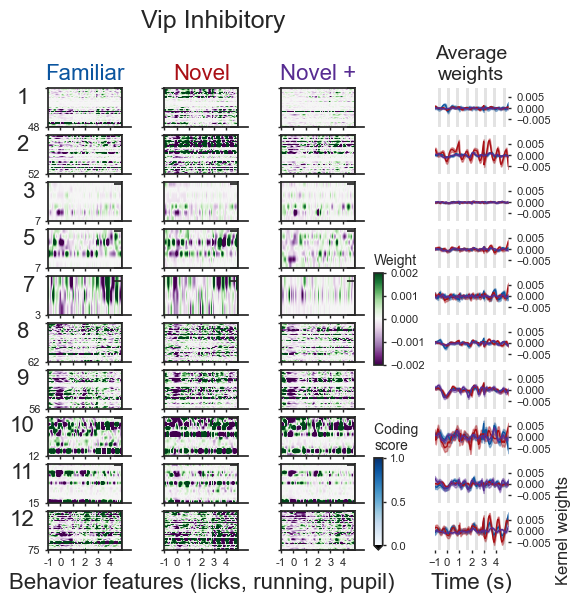

In [331]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = prepare_and_plot_concatenated_image_kernels(
    kernel_names=['licks', 'running', 'pupil'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Behavior features (licks, running, pupil)',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

#### Area and depth distributions

array([<AxesSubplot:title={'center':'Exc'}, ylabel='Cluster ID'>,
       <AxesSubplot:title={'center':'Sst'}, xlabel='Fraction cells in each area'>,
       <AxesSubplot:title={'center':'Vip'}>], dtype=object)

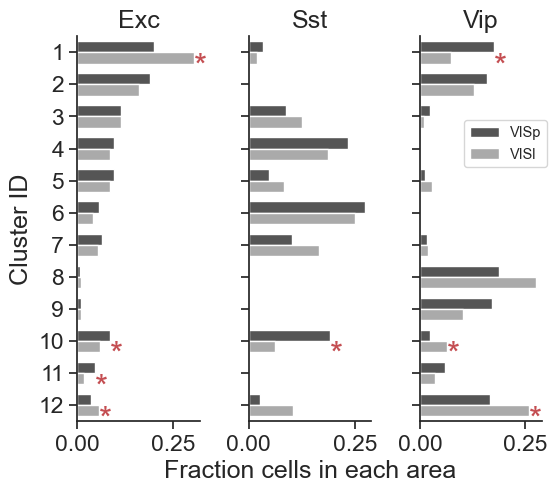

In [ ]:
location = 'targeted_structure'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each area'

plotting.plot_cluster_depth_distribution_by_cre_lines(cluster_meta, location, metric, horiz=False,
                                                      ylabel=ylabel, save_dir=save_dir, folder='cluster_properties')

In [ ]:
location = 'targeted_structure'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells\nin each area'

plotting.plot_cluster_depth_distribution_by_cre_line_separately(cluster_meta, location, cluster_order=None,
                                                            metric=metric, ylabel=ylabel, legend_title='', save_dir=save_dir, folder='cluster_properties')

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5405: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',


array([<AxesSubplot:title={'center':'Exc'}, ylabel='Cluster ID'>,
       <AxesSubplot:title={'center':'Sst'}, xlabel='Fraction cells in each depth'>,
       <AxesSubplot:title={'center':'Vip'}>], dtype=object)

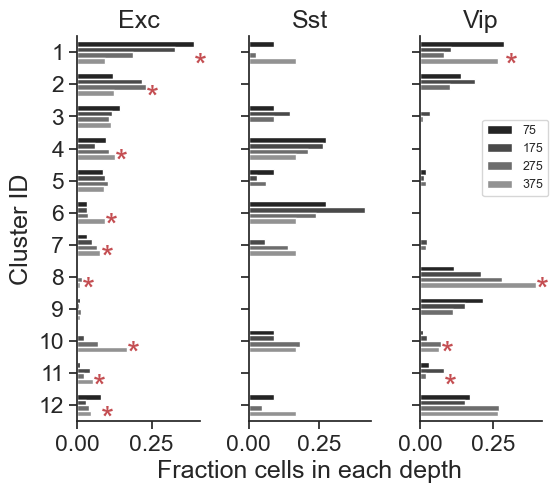

In [ ]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each depth'

plotting.plot_cluster_depth_distribution_by_cre_lines(cluster_meta, location, metric, horiz=False,
                                                      ylabel=ylabel, save_dir=save_dir, folder='cluster_properties')

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5496: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(data=cre_data, x='cluster_id', order=order, y=metric,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5496: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(data=cre_data, x='cluster_id', order=order, y=metric,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\dimensionality_reduction\clustering\plotting.py:5496: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(data=cre_data, x='cluster_id', order=order, y=metric,


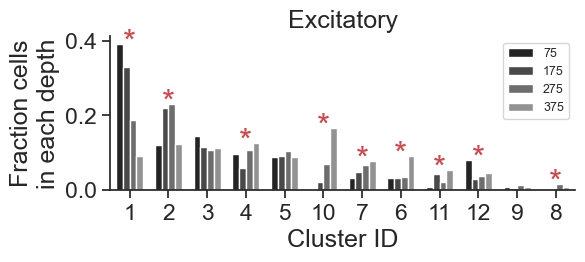

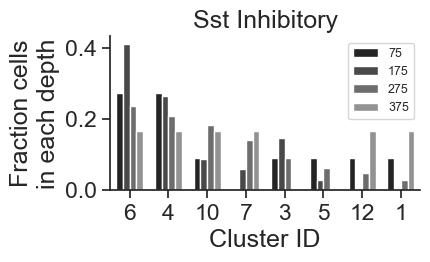

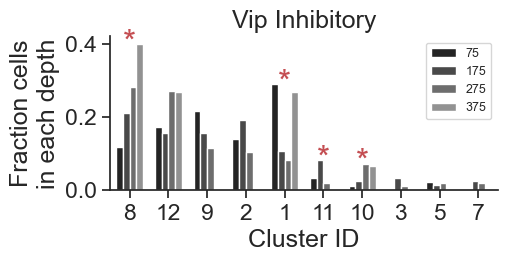

In [ ]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells\nin each depth'


plotting.plot_cluster_depth_distribution_by_cre_line_separately(cluster_meta, location, cluster_order=None,
                                                            metric=metric, ylabel=ylabel, legend_title='', save_dir=save_dir, folder='cluster_properties')

### Validating clusters via prediction strength

##### validate pre-determined clusters

1) split data into test and training set
2) train a classifier to predict the original cluster labels using the training set, then predict the cluster IDs in the test set using this classifier
3) find cells in test set belonging to each original cluster and ask what proportion of those cell pairs have the same predicted label in the test prediction (prediction based on training classifier trained to learn the original cluster IDs)
4) compute minimum proportion of matching pairs across the original set of clusters. 

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = feature_matrix.loc[cluster_meta.index.values]
pre_determined_labels = cluster_meta.cluster_id.values
X_tr, X_te, L_tr, L_te = train_test_split(X, pre_determined_labels, test_size=0.5, random_state=42)

In [ ]:
def get_robustness_of_labels(X, pre_determined_labels, n_neighbors=5, n_iters=10):
    """
    Computes the prediction strength for a set of fixed labels.
    
    Args:
        X: Feature matrix (3000, 9).
        pre_determined_labels: The labels you want to test.
        n_neighbors: KNN neighbors (best match for original spectral clustering method).
    """
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier
    from scipy.special import comb

    cluster_ids = np.sort(np.unique(pre_determined_labels))
    scores = []
    all_cluster_strengths = []

    ps_df = []

    for i in range(n_iters):
        # 1. Split data and labels
        X_train, X_test, labels_training, labels_test = train_test_split(
            X, pre_determined_labels, test_size=0.5, random_state=i)

        # 2. Train a KNN 'Surrogate' on the training labels
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train, labels_training)

        # 3. Predict labels for the test set
        test_predictions = knn.predict(X_test)

        # 4. Calculate prediction strength for each original cluster
        cluster_strengths = []
        for cluster_id in cluster_ids:
            # Indices of points that belong to this cluster in the TEST set
            indices = np.where(labels_test == cluster_id)[0]
            n_kj = len(indices)
            
            if n_kj < 2: continue
            
            # How many of these points share a predicted label?
            preds = test_predictions[indices]
            _, counts = np.unique(preds, return_counts=True)
            
            same_predict_pairs = np.sum(comb(counts, 2))
            total_pairs = comb(n_kj, 2)
            strength = same_predict_pairs / total_pairs
            cluster_strengths.append(strength)
            ps_df.append([i, cluster_id, strength])
        
        all_cluster_strengths.append(cluster_strengths)
        scores.append(np.min(cluster_strengths))

    prediction_score = np.mean(scores)
    prediction_sem = np.std(scores) / np.sqrt(n_iters)

    ps_df = pd.DataFrame(data=ps_df, columns=['iteration', 'cluster_id', 'cluster_strength'])

    return ps_df, prediction_score, prediction_sem, all_cluster_strengths


In [ ]:
X = feature_matrix.loc[cluster_meta.index.values]
original_cluster_labels = cluster_meta.cluster_id.values

ps_df, prediction_score, prediction_sem, all_cluster_strengths = get_robustness_of_labels(X, original_cluster_labels)
print(np.round(prediction_score, 2), np.round(prediction_sem, 2))

0.33 0.02


In [ ]:
ps_df

,iteration,cluster_id,cluster_strength
0,0,1,1.000000
1,0,2,0.953140
2,0,3,0.848308
3,0,4,0.918116
4,0,5,0.915330
...,...,...,...
115,9,8,0.836353
116,9,9,0.719873
117,9,10,0.317650
118,9,11,0.706775


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_69945/85751635.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=ps_df, x='cluster_id', y='cluster_strength', join=False, zorder=1000, ax=ax)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


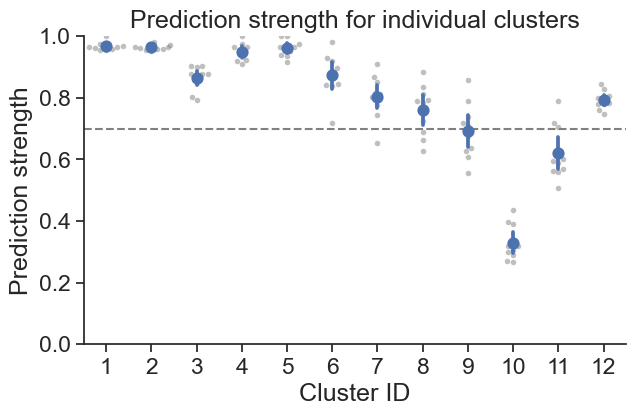

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ax = sns.swarmplot(data=ps_df, x='cluster_id', y='cluster_strength', color='gray', alpha=0.5, size=4, ax=ax)
ax = sns.pointplot(data=ps_df, x='cluster_id', y='cluster_strength', join=False, zorder=1000, ax=ax)

ax.set_title('Prediction strength for individual clusters')
ax.set_ylabel('Prediction strength')
ax.set_xlabel('Cluster ID')
ax.set_ylim(0, 1)
ax.axhline(y=0.7, xmin=0, xmax=1, linestyle='--', color='gray')

##### Compare to cluster size

In [ ]:
tmp = cluster_meta.copy()
tmp['cre_line'] = 'all'
n_cells_per_cluster = processing.get_fraction_cells_per_cluster_per_group(tmp, col_to_group='cre_line')
n_cells_per_cluster['percent_cells'] = n_cells_per_cluster.fraction_per_cluster * 100
n_cells_per_cluster

,cre_line,cluster_id,n_cells_cluster,n_cells_group,fraction_per_cluster,percent_cells
0,all,1,789,3901,0.202256,20.225583
1,all,2,673,3901,0.172520,17.251987
2,all,3,404,3901,0.103563,10.356319
3,all,4,356,3901,0.091259,9.125865
4,all,5,328,3901,0.084081,8.408100
5,all,6,229,3901,0.058703,5.870290
6,all,7,234,3901,0.059985,5.998462
7,all,8,112,3901,0.028711,2.871059
8,all,9,92,3901,0.023584,2.358370
9,all,10,311,3901,0.079723,7.972315


In [ ]:
mean_ps_df = ps_df.groupby(['cluster_id']).mean()
mean_ps_df = mean_ps_df.merge(n_cells_per_cluster[['cluster_id', 'percent_cells']], on=['cluster_id'])
mean_ps_df.head()

,cluster_id,iteration,cluster_strength,percent_cells
0,1,4.5,0.967819,20.225583
1,2,4.5,0.964259,17.251987
2,3,4.5,0.865954,10.356319
3,4,4.5,0.949537,9.125865
4,5,4.5,0.961338,8.408100


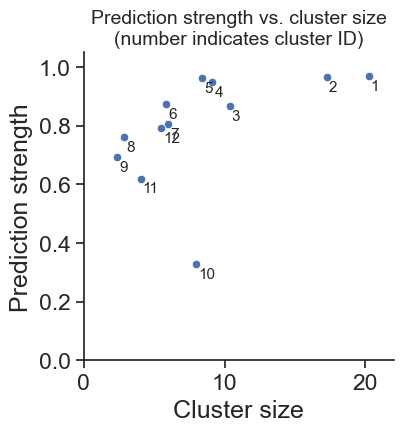

In [ ]:
figsize = (4,4)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.scatterplot(data=mean_ps_df, x='percent_cells', y='cluster_strength')
ax.set_xlim(0, 22)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Prediction strength')
ax.set_xlabel('Cluster size')
ax.set_title('Prediction strength vs. cluster size\n(number indicates cluster ID)', fontsize=14)
for cluster_id in mean_ps_df.cluster_id.unique(): 
    row_data = mean_ps_df[mean_ps_df.cluster_id==cluster_id]
    ax.text(s=str(row_data.cluster_id.values[0]), fontsize=11, ha='left', va='top',
            x=row_data.percent_cells.values[0]+0.15, y=row_data.cluster_strength.values[0]-0.01)

##### Robustness of clusters for individual cre lines

In [ ]:
counts = pd.DataFrame(cluster_meta.value_counts(['cell_type', 'cluster_id']), columns=['n_cells']).reset_index().sort_values(by=['cell_type', 'cluster_id'])
clusters_to_remove = counts[counts.n_cells<10]
clusters_to_remove

,cell_type,cluster_id,n_cells
29,Sst Inhibitory,1,6
25,Sst Inhibitory,12,9
26,Vip Inhibitory,3,8
28,Vip Inhibitory,5,7
27,Vip Inhibitory,7,7


In [ ]:
cells_to_remove = []
for i, row_data in clusters_to_remove.iterrows():
    csids = cluster_meta[(cluster_meta.cell_type==row_data.cell_type) & (cluster_meta.cluster_id==row_data.cluster_id)].index.values
    cells_to_remove = np.hstack((cells_to_remove, csids))

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_69945/1076826168.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=df, x='cluster_id', y='cluster_strength', hue='cell_type',


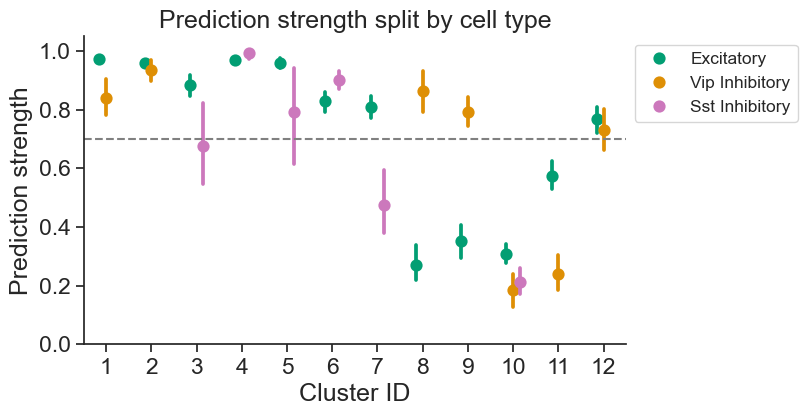

In [ ]:
cluster_meta_tmp = cluster_meta.copy()
cluster_meta_tmp = cluster_meta_tmp.drop(index=cells_to_remove)

df = pd.DataFrame()
for cell_type in cell_types: 
    cre_cluster_meta = cluster_meta_tmp[cluster_meta_tmp.cell_type==cell_type]
    X = feature_matrix.loc[cre_cluster_meta.index.values]
    original_cluster_labels = cre_cluster_meta.cluster_id.values

    ps_df, prediction_score, prediction_sem, all_cluster_strengths = get_robustness_of_labels(X, original_cluster_labels)
    ps_df['cell_type'] = cell_type
    df = pd.concat([df, ps_df])

fig, ax = plt.subplots(figsize=(7,4))
ax = sns.pointplot(data=df, x='cluster_id', y='cluster_strength', hue='cell_type', 
                   palette=utils.get_cell_type_colors(), join=False, dodge=0.3, ax=ax)
ax.legend(bbox_to_anchor=(1,1), fontsize='x-small', title='')
ax.set_title('Prediction strength split by cell type')
ax.set_ylabel('Prediction strength')
ax.set_xlabel('Cluster ID')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.7, xmin=0, xmax=1, linestyle='--', color='gray')

### Prediction Strength Analysis

In [ ]:
def get_train_test_predict_labels_KMeans(feature_matrix, n_clusters, iteration=42):
    """
    Run clustering on train and test sets, then predict labels in test set
    using training set model (nearest centroid assignment).
    """
    from sklearn.cluster import KMeans
    from sklearn.model_selection import train_test_split

    X = feature_matrix.copy()
    X_train, X_test = train_test_split(X, test_size=0.5, random_state=iteration)

    model_train = KMeans(n_clusters=n_clusters, random_state=iteration, n_init=10)
    model_train.fit(X_train)
    train_labels = model_train.labels_
    train_centers = model_train.cluster_centers_

    test_predictions = model_train.predict(X_test)

    model_test = KMeans(n_clusters=n_clusters, random_state=iteration, n_init=10)
    test_labels = model_test.fit_predict(X_test)

    return X_train, X_test, train_labels, test_labels, test_predictions


def get_prediction_strength(test_labels, test_predictions):
    """
    Computes prediction strength for a clustering.

    Args:
        test_labels: Labels from clustering test set independently.
        test_predictions: Labels from assigning test data to training centroids.

    Returns:
        DataFrame with prediction strengths per cluster.
    """
    unique_test_clusters = np.unique(test_labels)
    k = len(unique_test_clusters)

    if k == 1:
        return pd.DataFrame([[-1, 1.0]], columns=['cluster_number', 'prediction_strength'])

    strengths = []

    for cluster_num in unique_test_clusters:
        indices = np.where(test_labels == cluster_num)[0]
        n_cells_in_test_cluster = len(indices)

        if n_cells_in_test_cluster <= 2:
            strengths.append([cluster_num, 0])
            continue

        pred_in_cluster = test_predictions[indices]
        cluster_ids, counts = np.unique(pred_in_cluster, return_counts=True)

        same_predict_pairs = np.sum(comb(counts, 2))
        total_pairs = comb(n_cells_in_test_cluster, 2)
        strength = same_predict_pairs / total_pairs
        strengths.append([cluster_num, strength])

    return pd.DataFrame(strengths, columns=['cluster_number', 'prediction_strength'])


def get_prediction_strengths(X, n_iterations=5, max_n_clusters=20):
    """
    Compute prediction strength across multiple cluster numbers and iterations.
    """
    range_of_k = range(2, max_n_clusters)
    ps_scores_df = pd.DataFrame()

    for n_clusters in range_of_k:
        for iteration in range(n_iterations):
            X_train, X_test, train_labels, test_labels, test_predictions = \
                get_train_test_predict_labels_KMeans(X, n_clusters=n_clusters, iteration=iteration)
            ps_scores = get_prediction_strength(test_labels, test_predictions)
            ps_scores['n_clusters'] = n_clusters
            ps_scores['iteration'] = iteration
            ps_scores_df = pd.concat([ps_scores_df, ps_scores])

    return ps_scores_df


def get_mean_and_sem_ps_for_k_clusters(group, col='min'):
    """Helper function to compute mean and SEM for prediction strength."""
    sem = stats.sem(group[col].values)
    mean = np.mean(group[col].values)
    n_clusters = group.index.values[0][0]
    return pd.Series([mean, sem])


def get_mean_and_sem_across_iterations(scores_df, col='min'):
    """
    Compute mean and SEM of prediction strength across iterations.

    Args:
        col: 'min' for minimum PS, 'mean' for mean PS
    """
    scores_df_grouped = scores_df.groupby(['n_clusters', 'iteration']).describe()
    try:
        scores_df_grouped = scores_df_grouped.drop(columns=['cluster_number', 'cluster_id'])
    except:
        pass
    scores_df_grouped.columns = scores_df_grouped.columns.droplevel(0)

    scores_df_grouped = scores_df_grouped.groupby(['n_clusters']).apply(
        get_mean_and_sem_ps_for_k_clusters, col=col)
    scores_df_grouped.columns = [f'mean_{col}_ps', f'sem_{col}_ps']
    scores_df_grouped['threshold'] = scores_df_grouped[f'mean_{col}_ps'] + scores_df_grouped[f'sem_{col}_ps']
    scores_df_grouped = scores_df_grouped.reset_index()

    return scores_df_grouped



ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

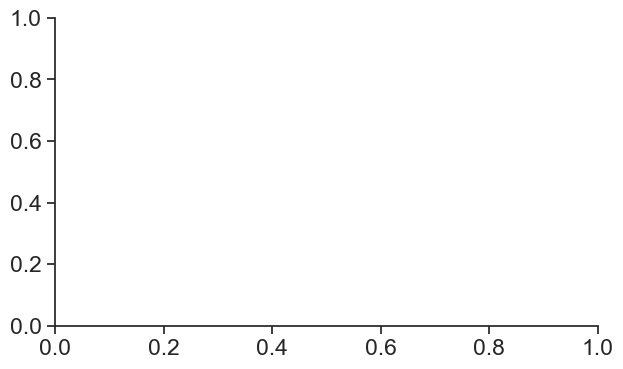

In [ ]:

# Run prediction strength analysis
# try:
X = feature_matrix.copy()
ps_scores_df = get_prediction_strengths(X, n_iterations=5, max_n_clusters=20)

# Plot minimum prediction strength
min_scores_df = get_mean_and_sem_across_iterations(ps_scores_df, col='min')

range_of_k = np.sort(min_scores_df.n_clusters.unique())
pred_strengths = min_scores_df.sort_values(by=['n_clusters'])['mean_min_ps'].values
yerr = min_scores_df.sort_values(by=['n_clusters'])['sem_min_ps'].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range_of_k, pred_strengths, yerr=yerr)
ax.set_ylim(0, 1)
ax.set_xlabel('# Clusters')
ax.set_ylabel('Minimum Prediction Strength')
ax.set_title(f'KMeans Prediction Strength (n={len(X)})')
ax.axhline(y=0.8, xmin=0, xmax=1, linestyle='--', color='gray')

try:
    selected_k = min_scores_df[min_scores_df['threshold'] > 0.8].sort_values(
        by=['n_clusters']
    )['n_clusters'].values[-1]
    ax.axvline(x=selected_k, ymin=0, ymax=1, linestyle='--', color='gray')
except:
    pass

fig.savefig(os.path.join(save_dir, 'prediction_strength_minimum.png'), dpi=150, bbox_inches='tight')
plt.close()

# Plot mean prediction strength
mean_scores_df = get_mean_and_sem_across_iterations(ps_scores_df, col='mean')

range_of_k = np.sort(mean_scores_df.n_clusters.unique())
pred_strengths = mean_scores_df.sort_values(by=['n_clusters'])['mean_mean_ps'].values
yerr = mean_scores_df.sort_values(by=['n_clusters'])['sem_mean_ps'].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range_of_k, pred_strengths, yerr=yerr)
ax.set_ylim(0, 1.05)
ax.set_xlabel('# Clusters')
ax.set_ylabel('Mean Prediction Strength')
ax.set_title(f'KMeans Mean Prediction Strength (n={len(X)})')
ax.axhline(y=0.8, xmin=0, xmax=1, linestyle='--', color='gray')

try:
    selected_k = mean_scores_df[mean_scores_df['threshold'] > 0.8].sort_values(
        by=['n_clusters']
    )['n_clusters'].values[-1]
    ax.axvline(x=selected_k, ymin=0, ymax=1, linestyle='--', color='gray')
except:
    pass

fig.savefig(os.path.join(save_dir, 'prediction_strength_mean.png'), dpi=150, bbox_inches='tight')
plt.close()

# Scatter plot of all prediction strength values
fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.scatterplot(data=ps_scores_df, x='n_clusters', y='prediction_strength',
                    color='k', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_xlabel('# Clusters')
ax.set_ylabel('Prediction Strength')
ax.set_title(f'Prediction Strength Across Clusters and Iterations (n={len(X)})')
ax.axhline(y=0.8, xmin=0, xmax=1, linestyle='--', color='gray')
ax.axhline(y=0.6, xmin=0, xmax=1, linestyle='--', color='gray')

fig.savefig(os.path.join(save_dir, 'prediction_strength_scatter.png'), dpi=150, bbox_inches='tight')


### Shuffle Control Analysis


In [ ]:
shuffle_control_dir = os.path.join(data_dir, 'shuffle_control')

# Load shuffled feature matrices
filepath = os.path.join(shuffle_control_dir, 'shuffled_feature_matrices.pkl')
if os.path.exists(filepath):
    with open(filepath, 'rb') as f:
        shuffled_feature_matrices = pickle.load(f)

    # Plot mean shuffled feature matrix
    plotting.plot_mean_shuffled_feature_matrix(
        shuffled_feature_matrices, original_cluster_meta,
        session_colors=True, experience_index=None,
        save_dir=save_dir, folder='shuffle_control')

# Load shuffled cluster labels and compute mean dropout scores
n_boots = np.arange(500)
filepath = os.path.join(shuffle_control_dir, 'shuffled_labels.pkl')
if os.path.exists(filepath):
    with open(filepath, 'rb') as f:
        shuffled_labels = pickle.load(f)

    # Compute mean dropout scores for original data
    original_mean_dropout_scores = processing.get_mean_dropout_scores_per_cluster(
        original_feature_matrix, cluster_meta=original_cluster_meta.reset_index(),
        sort_by_cluster_size=False)

    original_mean_dropout_scores_unstacked = processing.get_mean_dropout_scores_per_cluster(
        original_feature_matrix, stacked=False,
        cluster_meta=original_cluster_meta.reset_index(),
        sort_by_cluster_size=False)

    # Load mean dropout scores for shuffled data
    filepath_shuffled_scores = os.path.join(shuffle_control_dir, 'mean_dropout_scores_shuffled.pkl')
    if os.path.exists(filepath_shuffled_scores):
        with open(filepath_shuffled_scores, 'rb') as f:
            nb_mean_dropout_scores_shuffled = pickle.load(f)

    # Load SSE matrix and mapping
    SSE_matrix_filename = os.path.join(shuffle_control_dir, 'SSE_matrix_shuffled_nboot.pkl')
    with open(SSE_matrix_filename, 'rb') as f:
        SSE_matrix_dict = pickle.load(f)

    threshold = 0.15
    SSE_mapping = processing.get_cluster_mapping(SSE_matrix_dict, threshold=threshold)

    # Sort SSE values
    SSE_matrix_sorted = processing.sort_SSE_values(SSE_matrix_dict, SSE_mapping)

    # Get cluster means
    original_cluster_means = plotting.get_cluster_means(original_feature_matrix, original_cluster_meta)

    # Get shuffled cluster means
    nb_mean_dropout_scores_shuffled_unstacked = {}
    for n, n_boot in enumerate(n_boots):
        if n in shuffled_labels:
            cluster_meta_boot = shuffled_labels[n]
            feature_matrix_boot = shuffled_feature_matrices[n]
            mean_dropout_scores_unstacked = processing.get_mean_dropout_scores_per_cluster(
                feature_matrix_boot, cluster_meta=cluster_meta_boot,
                stacked=False, max_n_clusters=12)
            nb_mean_dropout_scores_shuffled_unstacked[n] = mean_dropout_scores_unstacked

    shuffled_clusters_dict = processing.get_matched_clusters_means_dict(
        SSE_mapping, nb_mean_dropout_scores_shuffled_unstacked,
        metric='mean', shuffle_type=None, cre_line=None)

    shuffled_cluster_means = processing.get_shuffled_cluster_means(shuffled_clusters_dict, 12)

    # Plot cluster heatmaps with SSE matrix
    plotting.plot_cluster_heatmaps_with_SSE_matrix(
        original_cluster_means, shuffled_cluster_means, SSE_matrix_sorted,
        session_colors=True, experience_index=None,
        save_dir=save_dir, folder='shuffle_control')

    # Plot matched clusters heatmap
    plotting.plot_matched_clusters_heatmap_remapped(
        shuffled_clusters_dict, abbreviate_features=False,
        abbreviate_experience=True, small_fontsize=False,
        session_colors=True, save_dir=save_dir, folder='shuffle_control')

    # Split shuffled dataframes by cre line
    shuffled_labels_cre = {}
    for cre_line in cre_lines:
        nb_labels_shuffled = {}
        for n_boot in n_boots:
            nb_labels_shuffled[n_boot] = shuffled_labels[n_boot][
                shuffled_labels[n_boot].cre_line == cre_line
            ]
        shuffled_labels_cre[cre_line] = nb_labels_shuffled

    # Compute cluster probabilities and plot
    cluster_probabilities = processing.compute_probabilities(SSE_mapping, shuffled_labels)
    probability_df = processing.get_cluster_probability_df(
        cluster_probabilities, cre_lines=None,
            columns=['cluster_id', 'probability'])
    
    plotting.plot_cluster_probability_for_shuffle(
        probability_df,
        save_dir=save_dir,
        folder='shuffle_control')

    # Compute cluster probabilities per cre line and plot
    cluster_probabilities_cre = {}
    for cre_line in cre_lines:
        cluster_probabilities_cre[cre_line] = processing.compute_probabilities(
            SSE_mapping,
            shuffled_labels_cre[cre_line])

    probability_df_cre = processing.get_cluster_probability_df(
        cluster_probabilities_cre,
        cre_lines=cre_lines,
        columns=['cre_line', 'cluster_id', 'probability'])
    plotting.plot_cluster_probability_for_shuffle(
        probability_df_cre,
        save_dir=save_dir,
        folder='shuffle_control',
        cre_lines=cre_lines)

    # Compute and plot cluster size differences
    normalize = True
    shuffled_cluster_sizes_cre = {}
    for cre_line in cre_lines:
        shuffled_cluster_sizes_cre[cre_line] = processing.get_cluster_size_variance(
            SSE_mapping,
            shuffled_labels_cre[cre_line],
            normalize=normalize)

    original_cluster_sizes_cre = {}
    for cre_line in cre_lines:
        cluster_meta_cre = original_cluster_meta[original_cluster_meta.cre_line == cre_line]
        original_cluster_sizes_cre[cre_line] = cluster_meta_cre.value_counts(
            'cluster_id',
            normalize=normalize
        ).reindex(range(1, n_clusters + 1))
        original_cluster_sizes_cre[cre_line] = original_cluster_sizes_cre[cre_line].replace(
            np.nan, 0)

    cluster_size_diff_cre = processing.get_cluster_size_differece_df(
        original_cluster_sizes_cre,
        shuffled_cluster_sizes_cre,
        cre_line=cre_lines)
    plotting.plot_cluster_size_difference_for_shuffle(
        cluster_size_diff_cre,
        y='abs_cluster_size_diff',
        save_dir=save_dir,
            folder='shuffle_control')


### Familiar-Only Clustering Control


In [ ]:
# Load cells matched across 3 familiar sessions
cells_table_familiar = processing.get_cells_matched_in_3_familiar_active_sessions()
cells_table_familiar["identifier"] = [
    str(cells_table_familiar.iloc[row].ophys_experiment_id) + "_" +
    str(cells_table_familiar.iloc[row].cell_specimen_id)
    for row in range(len(cells_table_familiar))
]
cells_table_familiar = cells_table_familiar.set_index("identifier")

# Load GLM results from local cache
glm_results_dir = loading.get_glm_results_dir()
run_params_path = os.path.join(glm_results_dir, glm_version + "_run_params.pkl")
with open(run_params_path, "rb") as f:
    run_params_fam = pickle.load(f)

results_pivoted_fam = pd.read_hdf(
    os.path.join(glm_results_dir, "across_session_normalized_platform_results_pivoted.h5"), key="df")

# Limit to familiar sessions only
results_pivoted_fam = results_pivoted_fam.drop(columns="experience_level")
results_pivoted_fam = results_pivoted_fam.merge(
    cells_table_familiar[["experience_level"]], on="identifier")

# Limit to features for clustering
features_list = ["all-images", "omissions", "task", "behavioral", "ophys_experiment_id"]
results_pivoted_fam = processing.limit_results_pivoted_to_features_for_clustering(
    results_pivoted_fam, features_list)

# Make coding scores positive
results_pivoted_fam = processing.flip_sign_of_dropouts(
    results_pivoted_fam, processing.get_features_for_clustering(),
    use_signed_weights=False)
results_pivoted_fam = results_pivoted_fam.drop(columns=["ophys_experiment_id"])

# Get feature matrix for familiar sessions
save_dir_familiar = os.path.join(data_dir, "familiar_only_clustering_without_problem_session")
os.makedirs(save_dir_familiar, exist_ok=True)

feature_matrix_familiar = processing.get_feature_matrix_for_clustering(
    results_pivoted_fam, glm_version, save_dir=save_dir_familiar)
feature_matrix_familiar = feature_matrix_familiar.rename(columns={
    "all-images": "images", "behavioral": "behavior"
})

# Load familiar clustering results
cluster_meta_familiar_path = os.path.join(
    save_dir_familiar, f"cluster_meta_n_{n_clusters_familiar}_clusters.h5")
cluster_meta_familiar = pd.read_hdf(cluster_meta_familiar_path, key="df")

# Plot familiar clustering results
plotting.plot_cre_line_means_remapped(
    feature_matrix_familiar, cluster_meta_familiar,
    session_colors=False, experience_index=0)

plotting.plot_cluster_means_remapped(
    feature_matrix_familiar, cluster_meta_familiar,
    session_colors=False, experience_index=0,
    save_dir=save_dir, folder="familiar_only_clustering")

plotting.plot_mean_cluster_heatmaps_remapped(
    feature_matrix_familiar, cluster_meta_familiar, None,
    session_colors=False, experience_index=0, save_dir=None, folder=None)

plotting.plot_fraction_cells_per_cluster_per_cre(
    cluster_meta_familiar, col_to_group="cre_line",
    save_dir=save_dir, folder="familiar_only_clustering")

print(f"Familiar-only clustering: {len(cluster_meta_familiar)} cells, "
      f"{cluster_meta_familiar.cluster_id.nunique()} clusters")


### Additional Cluster Characterization

In [ ]:
plotting.plot_coding_score_heatmap_matched(
    cluster_meta, feature_matrix, sort_by='cluster_id',
    session_colors=True, experience_index=None,
    save_dir=save_dir, folder='clustering_results')

# Cre-line means
plotting.plot_cre_line_means_remapped(
    feature_matrix, cluster_meta, session_colors=True,
    save_dir=save_dir, folder='clustering_results')

# Generate response metrics for difference of means analysis
response_metrics = processing.generate_merged_table_of_coding_score_and_model_free_metrics(
    cluster_meta,
    results_pivoted,
    data_type='events',
    session_subset='full_session',
    inclusion_criteria='platform_experiment_table',
    save_dir=os.path.join(platform_cache_dir, 'clustering'))

# Replace dominant experience level cluster with correct one
cluster_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)
cluster_metrics = cluster_metrics.rename(columns={
    'dominant_experience_level': 'dominant_experience_level_cluster',
    'dominant_feature': 'dominant_feature_cluster'
})

response_metrics = response_metrics.rename(columns={
    'dominant_experience_level_cluster': 'dominant_experience_level_old',
    'dominant_feature_cluster': 'dominant_feature_old'
})

response_metrics = response_metrics.merge(
    cluster_metrics.reset_index()[['cluster_id', 'dominant_experience_level_cluster', 'dominant_feature_cluster']])

# Plot difference of means with universal CI
from statsmodels.stats.multicomp import MultiComparison

metric = 'lifetime_sparseness_images'
title = 'Image selectivity\n(pref. exp. level)'
group_to_compare = 4

colors = plotting.get_pref_experience_level_colors_for_clusters(response_metrics)

pref_exp_response_metrics = response_metrics[
    (response_metrics.experience_level == response_metrics.dominant_experience_level)
]
response_metrics_clean = pref_exp_response_metrics.dropna(subset=[metric])

multi_comp = MultiComparison(response_metrics_clean[metric], response_metrics_clean['cluster_id'])
tukey_results = multi_comp.tukeyhsd()

plotting.plot_difference_of_means_and_universal_CI(
    tukey_results,
    group_to_compare=group_to_compare,
    group_colors=colors,
    color='k',
    title=title,
    xlabel='Difference in means',
    ylabel='Cluster ID',
    ax=None)


### Activity Metrics for Clusters

Distribution of model-free response metrics for each cluster, separated by experience level and cell type.
Metrics include: image selectivity (lifetime sparseness), response reliability, change modulation,
choice modulation (hit vs miss), omission modulation, and running modulation.

In [ ]:
# # Generate merged table of coding scores and model-free metrics
# clustering_results = loading.get_clustering_results_dir()
# metrics = processing.generate_merged_table_of_coding_score_and_model_free_metrics(
#     cluster_meta, results_pivoted,
#     data_type='events',
#     session_subset='full_session',
#     inclusion_criteria='platform_experiment_table',
#     save_dir=clustering_results)

# # Get cluster-level dominant experience level and feature assignments
# cluster_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)
# cluster_metrics = cluster_metrics.rename(columns={
#     'dominant_experience_level': 'dominant_experience_level_cluster',
#     'dominant_feature': 'dominant_feature_cluster'
# })

# # Replace old columns with correct ones
# metrics = metrics.rename(columns={
#     'dominant_experience_level_cluster': 'dominant_experience_level_old',
#     'dominant_feature_cluster': 'dominant_feature_old'
# })

# response_metrics = metrics.merge(
#     cluster_metrics.reset_index()[['cluster_id', 'dominant_experience_level_cluster', 'dominant_feature_cluster']]
# )

# print(f'{len(response_metrics.cell_specimen_id.unique())} cells with response metrics')

loading coding score and model free metrics table
3901 cells with response metrics


array([<Axes: title={'center': 'Excitatory'}, xlabel='Cluster ID', ylabel='Image selectivity'>,
       <Axes: title={'center': 'Sst Inhibitory'}, xlabel='Cluster ID'>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Cluster ID'>],
      dtype=object)

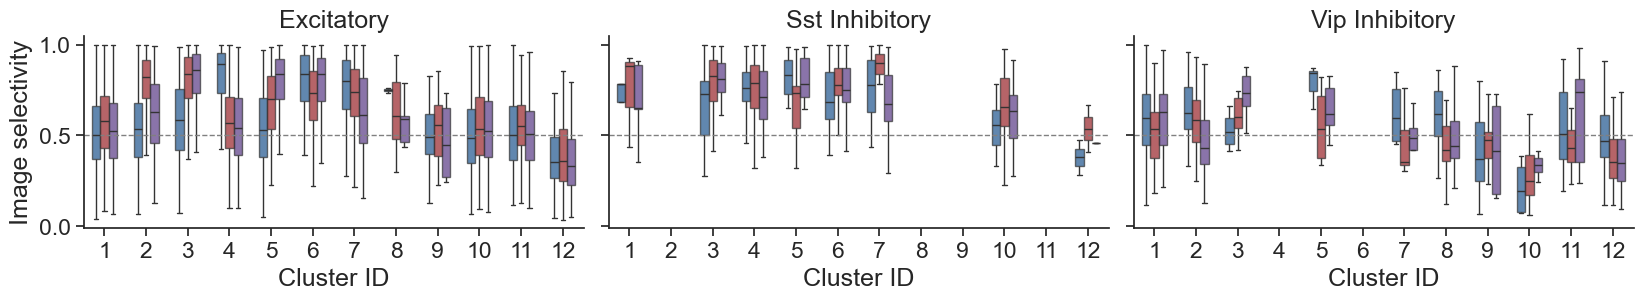

In [ ]:
metric = 'lifetime_sparseness_images'
ylabel = 'Image selectivity'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True, line_val=0.5,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')


In [ ]:
metric = 'reliability_pref_image'
ylabel = 'Response reliability\n(preferred image)'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True, line_val=0,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')

plotting.plot_response_metrics_boxplot_by_cre_as_cols(response_metrics, metric, label=ylabel, horiz=False, line_val=0,
                                             save_dir=save_dir, folder='S23')

In [ ]:
metric = 'change_modulation_index'
ylabel = 'Change modulation'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True, line_val=0,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')

plotting.plot_response_metrics_boxplot_by_cre_as_cols(response_metrics, metric, label=ylabel, horiz=False, line_val=0,
                                             save_dir=save_dir, folder='S23')

In [ ]:
metric = 'hit_miss_index'
ylabel = 'Choice modulation'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True, line_val=0,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')

In [ ]:
metric = 'omission_modulation_index'
ylabel = 'Omission modulation'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True, line_val=0,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')


In [ ]:
metric = 'running_modulation_all_images'
ylabel = 'Running modulation'

plotting.plot_response_metrics_boxplot_by_cre(response_metrics, metric, ylabel=ylabel, horiz=True,
                                              save_dir=save_dir, folder='S23', suffix='_horiz')

### Average Metric Values for Preferred Experience Level

Average value of each response metric across neurons for each cluster, shown for the experience level
with the highest overall coding score. A reference cluster is selected for each metric and significance
is assessed via Tukey HSD (p=0.05). Data points are colored by dominant experience level.
Split by cell type (Excitatory, Sst, Vip).

In [ ]:
metric = 'lifetime_sparseness_images'
title = 'Image selectivity'
xlabel = 'Image selectivity'
group_to_compare = 4

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-0.1, 1.1),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

In [ ]:
metric = 'reliability_pref_image'
title = 'Reliability'
xlabel = 'Response reliability\n(preferred image)'
group_to_compare = 4

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-0.1, 0.5),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

In [ ]:
metric = 'change_modulation_index'
title = 'Change modulation'
xlabel = 'Change modulation'
group_to_compare = 11

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-1.1, 1.1),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

In [ ]:
metric = 'hit_miss_index'
title = 'Choice modulation'
xlabel = 'Choice modulation'
group_to_compare = 11

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-1.1, 1.1),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

In [ ]:
metric = 'omission_modulation_index'
title = 'Omission modulation'
xlabel = 'Omission modulation'
group_to_compare = 8

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-1.1, 1.6),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

In [ ]:
metric = 'running_modulation_all_images'
title = 'Running modulation'
xlabel = 'Running modulation'
group_to_compare = 12

plotting.plot_tukey_diff_in_means_for_metric(response_metrics, metric, horiz=False, lims=(-1.1, 1.1),
                                    title=title, xlabel=xlabel, group_to_compare=group_to_compare,
                                    pref_exp_level=True, split_by_cre=True,
                                    save_dir=save_dir, folder='S24')

### Experience modulation across clusters

Generating Panel F: Experience modulation...
loading coding score metrics table


<Axes: title={'center': 'Novelty modulation'}, xlabel='Cluster ID', ylabel='<- Familiar --- Novel ->'>

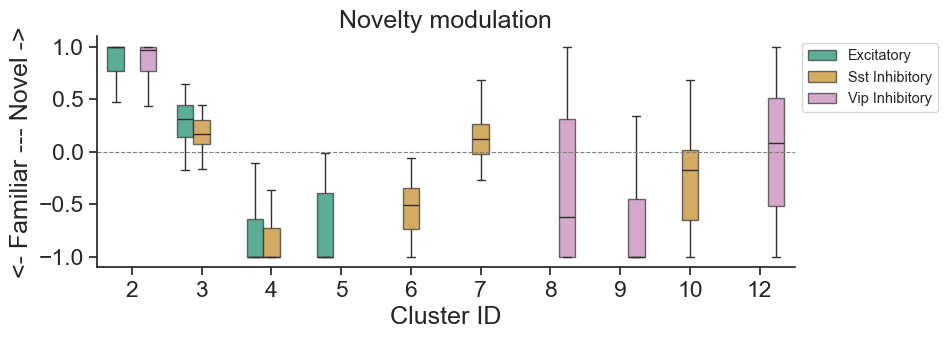

In [ ]:
print("Generating Panel F: Experience modulation...")

# Generate coding score metrics
coding_score_metrics = processing.generate_coding_score_metrics_table(
    cluster_meta,
    results_pivoted,
    save_dir=clustering_dir)

# Filter to clusters with sufficient cell counts per cre line
# Compute cluster proportions per cre line
_counts = cluster_meta.groupby(['cre_line', 'cluster_id']).size().reset_index(name='n_cells')
_totals = cluster_meta.groupby('cre_line').size().reset_index(name='n_cells_total')
n_cells_per_cluster = _counts.merge(_totals, on='cre_line')
n_cells_per_cluster['fraction_per_cluster'] = n_cells_per_cluster['n_cells'] / n_cells_per_cluster['n_cells_total']
small_clusters = n_cells_per_cluster[
    n_cells_per_cluster.fraction_per_cluster < 0.09
].set_index(['cre_line', 'cluster_id']).index.values
small_clusters = np.unique(small_clusters)

coding_score_metrics_filtered = coding_score_metrics.copy()
for small_cluster in small_clusters:
    csids = coding_score_metrics[
        (coding_score_metrics.cre_line == small_cluster[0]) &
        (coding_score_metrics.cluster_id == small_cluster[1])
    ].index.values
    coding_score_metrics_filtered = coding_score_metrics_filtered.drop(index=csids)

# Remove non-coding cluster
csids = coding_score_metrics_filtered[coding_score_metrics_filtered.cluster_id == 1].index.values
coding_score_metrics_filtered = coding_score_metrics_filtered.drop(index=csids)

# Plot experience modulation
plotting.plot_experience_modulation(
    coding_score_metrics_filtered,
    metric='experience_modulation',
    save_dir=save_dir,
    folder='figure_5_panels')


loading coding score metrics table


<AxesSubplot:title={'center':'Novelty modulation'}, xlabel='Cluster ID', ylabel='<- Familiar --- Novel ->'>

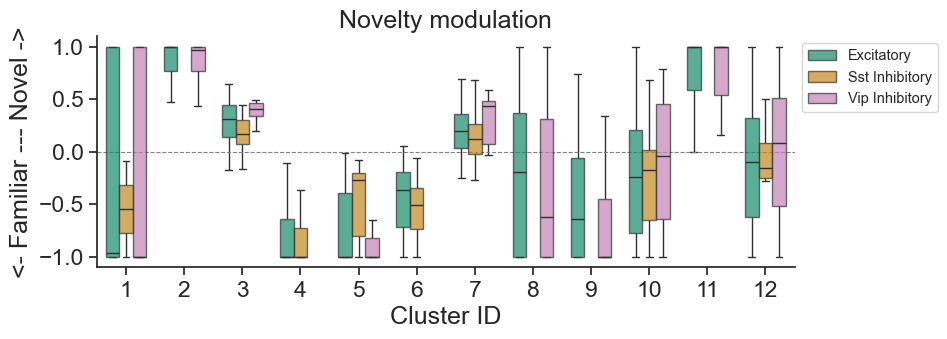

In [ ]:
# load pre-saved coding score metrics 
coding_score_metrics = processing.generate_coding_score_metrics_table(cluster_meta, results_pivoted, 
                                                                      save_dir=clustering_results)

# metric comparing N to avg of F and N+
plotting.plot_experience_modulation(coding_score_metrics, metric='experience_modulation', save_dir=None, 
                                    folder='metric_distributions', suffix='_all_clusters')

#### filter coding scores to limit to clusters with >3.5% of cells per cre and plot experience modulation

In [ ]:
# which clusters are removed if you eliminate those with <3.5% of all cells in that cre line?
n_cells_table = processing.get_cluster_proportion_stats_for_locations(cluster_meta, location=location)
n_cells_table[n_cells_table.fraction_cells_cluster<0.035].reset_index().set_index(['cre_line', 'cluster_id'])

targeted_structure  n_cells_location  \
cre_line          cluster_id                                        
Slc17a7-IRES2-Cre 8                        VISl                 6   
                  8                        VISp                19   
                  9                        VISl                 6   
                  9                        VISp                23   
Sst-IRES-Cre      1                        VISl                 1   
                  1                        VISp                 5   
Vip-IRES-Cre      3                        VISl                 1   
                  3                        VISp                 7   
                  5                        VISl                 3   
                  5                        VISp                 4   
                  7                        VISl                 2   
                  7                        VISp                 5   
                  10                       VISl                 7   
                  10                       VISp                 7   

                              n_cells_location_total  fraction_cells_location  \
cre_line          cluster_id                                                    
Slc17a7-IRES2-Cre 8                              590                 0.010169   
                  8                             2708                 0.007016   
                  9                              590                 0.010169   
                  9                             2708                 0.008493   
Sst-IRES-Cre      1                               48                 0.020833   
                  1                              146                 0.034247   
Vip-IRES-Cre      3                              108                 0.009259   
                  3                              301                 0.023256   
                  5                              108                 0.027778   
                  5                              301                 0.013289   
                  7                              108                 0.018519   
                  7                              301                 0.016611   
                  10                             108                 0.064815   
                  10                             301                 0.023256   

                              percent_cells_location  n_cells_cluster  \
cre_line          cluster_id                                            
Slc17a7-IRES2-Cre 8                         1.016949               25   
                  8                         0.701625               25   
                  9                         1.016949               29   
                  9                         0.849335               29   
Sst-IRES-Cre      1                         2.083333                6   
                  1                         3.424658                6   
Vip-IRES-Cre      3                         0.925926                8   
                  3                         2.325581                8   
                  5                         2.777778                7   
                  5                         1.328904                7   
                  7                         1.851852                7   
                  7                         1.661130                7   
                  10                        6.481481               14   
                  10                        2.325581               14   

                              n_cells_cre  fraction_cells_cluster  \
cre_line          cluster_id                                        
Slc17a7-IRES2-Cre 8                  3298                0.007580   
                  8                  3298                0.007580   
                  9                  3298                0.008793   
                  9                  3298                0.008793   
Sst-IRES-Cre      1                   194   

3901 total cells
3805 after removing clusters with < 4% of cells in a given cre line


<AxesSubplot:title={'center':'Novelty modulation'}, xlabel='Cluster ID', ylabel='<- Familiar --- Novel ->'>

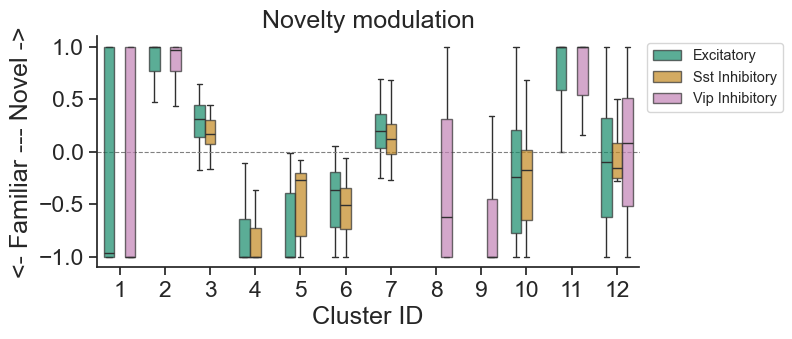

In [ ]:
location = 'layer'
order = ['upper', 'lower']
n_cells_table = processing.get_cluster_proportion_stats_for_locations(cluster_meta, location=location)
small_clusters = n_cells_table[n_cells_table.fraction_cells_cluster<0.035].reset_index().set_index(['cre_line', 'cluster_id']).index.values
small_clusters = np.unique(small_clusters)


coding_score_metrics_filtered = coding_score_metrics.copy()
for small_cluster in small_clusters: 
    csids = coding_score_metrics[(coding_score_metrics.cre_line==small_cluster[0]) & (coding_score_metrics.cluster_id==small_cluster[1])].index.values
    coding_score_metrics_filtered = coding_score_metrics_filtered.drop(index=csids)

print(len(coding_score_metrics), 'total cells')
print(len(coding_score_metrics_filtered), 'after removing clusters with < 4% of cells in a given cre line')


# metric comparing N to avg of F and n+
plotting.plot_experience_modulation(coding_score_metrics_filtered, metric='experience_modulation', save_dir=None, 
                                    folder='metric_distributions', suffix='_filtered_clusters')